RAG流程：**多数据源**构建外部数据库——**文档切分**（平衡语意完整性和效率）——**向量化**（嵌入模型）——**向量数据库**

query问题——向量

query和向量数据库里的向量的**相似度检索**——**rerank**对检索的知识重新排序，选择最相关的片段作为生成阶段的输入——**筛选过滤文档**

上下文组装——**大模型生成**

检索 上下文管理 提示词拼接

如果企业的知识库更新比较频繁的话，推荐使用RAG，如果需要建立客服形象，如果需要有固定的流程，推荐模型微调。

但是模型微调的成本会比RAG高一些。

RAG本质上是重构了一个新的prompt

langchain可以拼接很多任务，主要注重流程控制。（涉及需要多个步骤的流程，需要处理多个任务，需要集成外部数据源，需要调用工具）。

LlamaIndex更加适合去做检索，怎么加数据，怎么做索引，怎么高效查找。（适合大量文档，要对文档进行快速解锁的情况）。

配合起来，langchain做前端，LlamaIndex管理文档。

agent用来决定是用大模型自己的生成能力还是使用tool。

MCP和langchain的功能是一样的，但是框架和方法是不一样的。

# **LangChain=大模型应用开发框架**



| 功能      | 组件名称（LangChain）                       | 说明                                                                                                                     |
| ------- | ------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| 数据输入    | **DocumentLoaders**                   | 从不同数据源加载文档，例如 `PyPDFLoader`（PDF）、`UnstructuredHTMLLoader`（HTML）、`TextLoader`（TXT/Markdown）、`DirectoryLoader`（目录批量导入）等。 |
| 文本分块    | **Text Splitters**                    | 将长文档切成小块，方便向量化与检索。例如 `RecursiveCharacterTextSplitter` 支持按层级分割并可设定重叠窗口。                                                 |
| 向量化     | **Embeddings**                        | 将文本块转为向量，如 `OpenAIEmbeddings`、`HuggingFaceEmbeddings`、`GPT4AllEmbeddings` 等。                                           |
| 向量存储   | **VectorStores**                      | 存储向量并提供相似度检索接口，如 `FAISS`、`Chroma`、`Pinecone`、`Weaviate` 等，支持 `vectorstore.as_retriever()` 创建检索器。                       |
| 检索器    | **Retrievers**                        | 抽象的检索层，可基于向量、关键词或混合检索；`VectorStoreRetriever` 是最常用实现。                                                                   |
| 重排序（可选） | **Rerankers / Custom Retriever**      | 对检索到的文档片段重新排序，可用外部模型或自定义函数实现。                                                                                          |
| 提示模板    | **PromptTemplate**                    | 定义模型提示词模板，将检索结果与用户查询拼接到固定格式中。                                                                                          |
| 问答链路    | **RetrievalQA**                       | LangChain 内置的端到端 RAG 封装，`RetrievalQA` 会调用 Retriever 获取上下文并传入 LLM 生成答案。                                                 |
| 模型调用    | **LLMs / ChatModels**                 | 调用大语言模型生成回答，如 `OpenAI`、`ChatOpenAI`、`ChatAnthropic` 等。                                                                 |
| 上下文管理   | **Stuff / MapReduce / Refine Chains** | 不同的文档组合策略，控制如何将多个检索结果送入 LLM（Stuff 全量拼接、MapReduce 分批汇总、Refine 逐步补充）。                                                    |
| 评估与调试   | **LangSmith / Callbacks**             | 监控、日志记录和性能评估，便于调试和优化 RAG 流程。                                                                                           |


可以用这些组件去组装。

Prompt, LLM, Chain, Memory, Tool, Agent.六个核心组件。

1. prompt和业务强相关，用于出题（不如说告诉模型不会就不要乱答）。

2. huggingface上的模型是基座模型，不懂公司业务，私有数据。

3. 需要使用rag让它懂我们的数据，

4. 把行业数据发给模型再次进行训练，让它具备懂行业数据的能力，叫微调。

5. chain把大模型任务链给拼接起来。chain把不同的组件（retriever、prompt 模板、LLM 调用、输出解析器等）组织成一个工作流，按照固定的顺序运行。

chain = 一条按固定顺序连接多个步骤的执行链。

6. memory让多轮对话有记忆。即自动记住上下文信息。

7. agent 是一个“决策控制器”，它会动态选择要调用的工具（tools）或动作（actions）

colab不显示以.开头的文件。

为什么要使用.env文件？

1. 版本控制安全

当你把代码推送到GitHub、GitLab等平台时：

.env文件通常被添加到.gitignore中，不会被上传
避免API key意外公开，被他人盗用

2. 环境隔离

不同环境可以使用不同的配置，而代码保持不变。

3. 团队协作

每个开发者可以有自己的.env文件

不需要在代码中硬编码个人的API key

新成员只需要创建自己的.env文件

4. 安全审计

集中管理敏感信息

易于轮换API key


In [1]:
import os
print("exists?", os.path.exists("/content/.env"))

exists? True


In [2]:
!pip install langchain langchain-community langchainhub dashscope faiss-cpu python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.74
    Uninstalling langchain-core-0.

In [3]:
from langchain_community.chat_models import ChatTongyi #聊天模型
from langchain_community.vectorstores import FAISS #向量数据库
from langchain_community.embeddings import DashScopeEmbeddings #阿里的DashScope Embedding
from langchain_text_splitters import CharacterTextSplitter #文本切分工具
from langchain_community.document_loaders import TextLoader #读取本地text文件
#所有的文件都包含在document_loaders这个组件里，包括pdf,markdown等，只有txt文件用到TextLoader，langchain里面都封装好了。
from langchain.chains import RetrievalQA #RAG链
import os


通过os系统模块，直接读取到api_key

In [4]:
from dotenv import load_dotenv

In [5]:
load_dotenv()
api_key=os.getenv("DASHSCOPE_API_KEY")

**1. 初始化通义千问模型**

In [6]:
llm=ChatTongyi(model_name='qwen-turbo',dashscope_api_key=api_key)

因为模型是跑在阿里云的，所以此地用到api_key进行授权。

大模型不能去做检索，只能负责最后去生成回答。

大模型对我们的知识库不了解，意味着我们要自己构建知识库。

**2. 加载知识库**，读取本地的.txt文件，作为知识数据源。

In [7]:

loader=TextLoader("kb.txt",encoding="utf-8")
docs=loader.load()

TextLoader 是 LangChain 里用来读取文本文件的一个类。记住文件路径、编码等信息，并且准备好在之后把文件内容读进来（但这一步还没读内容）。类似你创建一个文件读取器，把文件路径和编码方式先存起来。

.load() 是 TextLoader 对象的方法，用来真正读取文件内容。用来真正读取文件内容。读取完成后会把文件转换成 Document 对象列表（LangChain 里统一的文档数据结构）。列表的每个元素是一个 Document，包含：

page_content：文档的纯文本内容（字符串）

metadata：元数据（例如文件名、路径、来源等）

为什么要做这种类——对象的方式？

因为

一：同一的接口。

LangChain 里有很多不同类型的 Loader处理不同的数据，TextLoader（纯文本），CSVLoader（CSV 文件），UnstructuredPDFLoader（PDF 文件）等

但这些Loader都有统一的方法：.load()

→ 这样你在主流程中，不用关心文件格式，只要知道：docs = loader.load()

二：便于扩展

用类，可以继承和重写方法，方便扩展功能。

例如你想让 TextLoader 在 .load() 时自动去掉空行：

直接改写
class MyTextLoader(TextLoader):

    def load(self):

三：延迟执行（Lazy Loading）

创建 loader 对象时，只是保存参数（文件路径、编码等），不马上读文件。

真正需要的时候再 .load()，可以：

避免浪费内存和时间

在任务分布式执行时更好控制读取时机

四：方便和下游处理链配合

LangChain 下游的 TextSplitter、VectorStore、Retriever 等组件都要求输入是 list[Document]。

Loader 统一产出 Document，就能无缝对接下游，而不用你自己每次写转换代码。

**3. 切分知识库文件**

遇到pdf，图片，找工具去帮我们解决。

将大文本变成小片段。

为什么要做文档切分？方便向量化，更深一步是方便检索。

向量：文本变成一串数字，大模型可以读懂数字。

每300个字符切一块，块之间重叠20个字符。这是为了保证每块文本既不大，方便处理。又有上下文，避免断句。

选择token切分还是character切分。

你关心“费用/上下文超长” → 用 token 切分。
场景：RAG 里要“stuff/concat 多段文档进提示词”、需要在 4k/8k/32k/200k 等窗口内稳定塞满、不想溢出。

文本类型复杂（中英混排、代码块、表格、符号多）→ 用 token 切分。
因为同样 300 字符可能对应 120～600 tokens，波动太大。

只是做召回/检索（先向量化再取前 k，生成时再选少量片段）→ character 切分已足够，简单稳妥。
若后续拼接到提示词还会超长，再在“二次拼接阶段”做一次 token 级截断即可。

没有合适 tokenizer 或多模型混用 → 先 character 切分（简单可靠），
但建议在写入前加一层“token 校验”，超限就再切（见下方做法 ②）。

① 多数技术文档（比如你的铁路维修知识库）
用**“递归字符切分 + 语义分隔符”（段落/句子优先），同时让长度函数按 token 来计**：

这样既保留“在自然边界切”的优势，又能把块控制在稳定的 token 预算内。

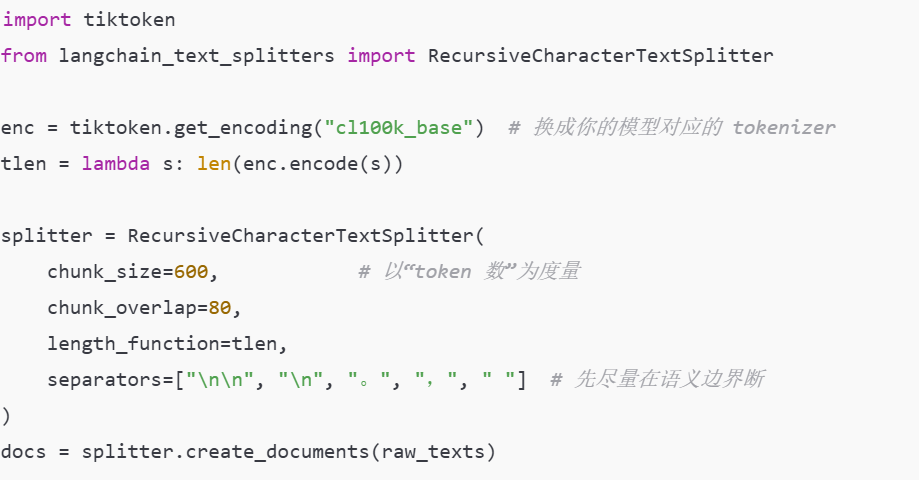

import tiktoken

from langchain_text_splitters import RecursiveCharacterTextSplitter

tiktoken：一个分词器库，encode() 会把字符串变成“token id 列表”。

RecursiveCharacterTextSplitter：递归式字符切分器，支持自定义“长度度量函数”。


enc = tiktoken.get_encoding("cl100k_base")

选择一个分词方案（tokenizer）。"cl100k_base" 是一套常用的 BPE 词表与规则。

你应尽量选择与你的模型一致的 tokenizer（不同模型的 token 规则不同）。


tlen = lambda s: len(enc.encode(s))

定义长度函数：输入字符串 s，先用 enc.encode(s) 得到 token 列表，再 len(...) 得到token 数。

这一步是关键：它把“长度的单位”从字符变成了token。


splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=80,
    length_function=tlen,          # ← 用上面按 token 计数的函数
    separators=["\n\n", "\n", "。", "，", " "]  # 优先在语义边界断开
)

length_function=tlen 告诉切分器：所有长度判断都按 token 数来算。于是：

chunk_size=600 → “每块最多 600 个 token”

chunk_overlap=80 → “相邻块重叠 80 个 token”

separators：从“大到小”的分隔符优先级，尽量在自然边界（段落/句子/空格）切；如果某段仍超过 chunk_size，再递归用更细的分隔符继续切，最后才可能在字符级硬切。

docs = splitter.create_documents([raw_text])

In [8]:
#创建对象
text_splitter=CharacterTextSplitter(chunk_size=300,chunk_overlap=20)
#调用对象的方法，把 docs 里的每个 Document 切分成多个小块，每一块都是一个新的 Document 对象
documents=text_splitter.split_documents(docs)

这段代码用的是 “定长上限 + 重叠（overlap）” 的策略：

每块的长度不超过 chunk_size=300 个字符，并在相邻块之间保留 chunk_overlap=20 个字符的重叠；为了尽量在自然边界（如换行、空格）断开，块的实际长度会有浮动，并不保证每块都正好 300 个字符。

再具体一点：

CharacterTextSplitter 会先按分隔符切（默认有换行等），再把片段按“≤300 字符”的约束打包成块；

如果某片段过长，会继续细分；

因为要顾及分隔符和 overlap，所以块长通常是 “≤300”、而非“=300”。

docs 也是一个 Document 对象的列表（list[Document]）。

切分策略：要和业务场景和数据量有关。同时要考虑模型能力，上下文窗口长度的限制。还有检索的精度。

切分大小：上下文大小限制，业务语意需求（overlap重叠是为了不要造成语意断裂）。

如果是FAQ客户问答语句，就按照问题和答案去切分。300-500token，重叠50token。（能保证语意的完整，并且每一段都能直接回答出来）。

合同按照条款去切分。500-800token，重叠100-200token。要保证法律的语意的单位，做精准匹配。

技术说明说按照标题和段落去切分。保留整体结构的信息完整性。这样能保证它的结构信息能做多段的一个组合。500-800token，重叠100-200token。

录音按照时间，或者上下文的轮次来做切分。

方便向量化（快）和检索。

长文本根据固定字数或者固定tokens，重叠滑窗。控制长度+避免语意断裂。重叠滑窗就是“每次滑动不走满块长，而是保留一段重叠”，确保跨边界的信息在至少一个块里完整出现。

举个最直观的例子（按“词”示意）：
文本 = A B C D E F G H I J K L

设 chunk_size=5，overlap=2 → stride=3

得到切分：

块1：A B C D E

块2：D E F G H（和块1重叠 D E）

块3：G H I J K（和块2重叠 G H）

通过不同切分策略切分后的文本可以存入同一个向量数据库：

是主流做法。关键是把两种来源（技术文档、Q/A）的chunk 统一成同一套 schema，用 metadata 区分，并保证用同一个 embedding 模型（维度一致）来建索引。



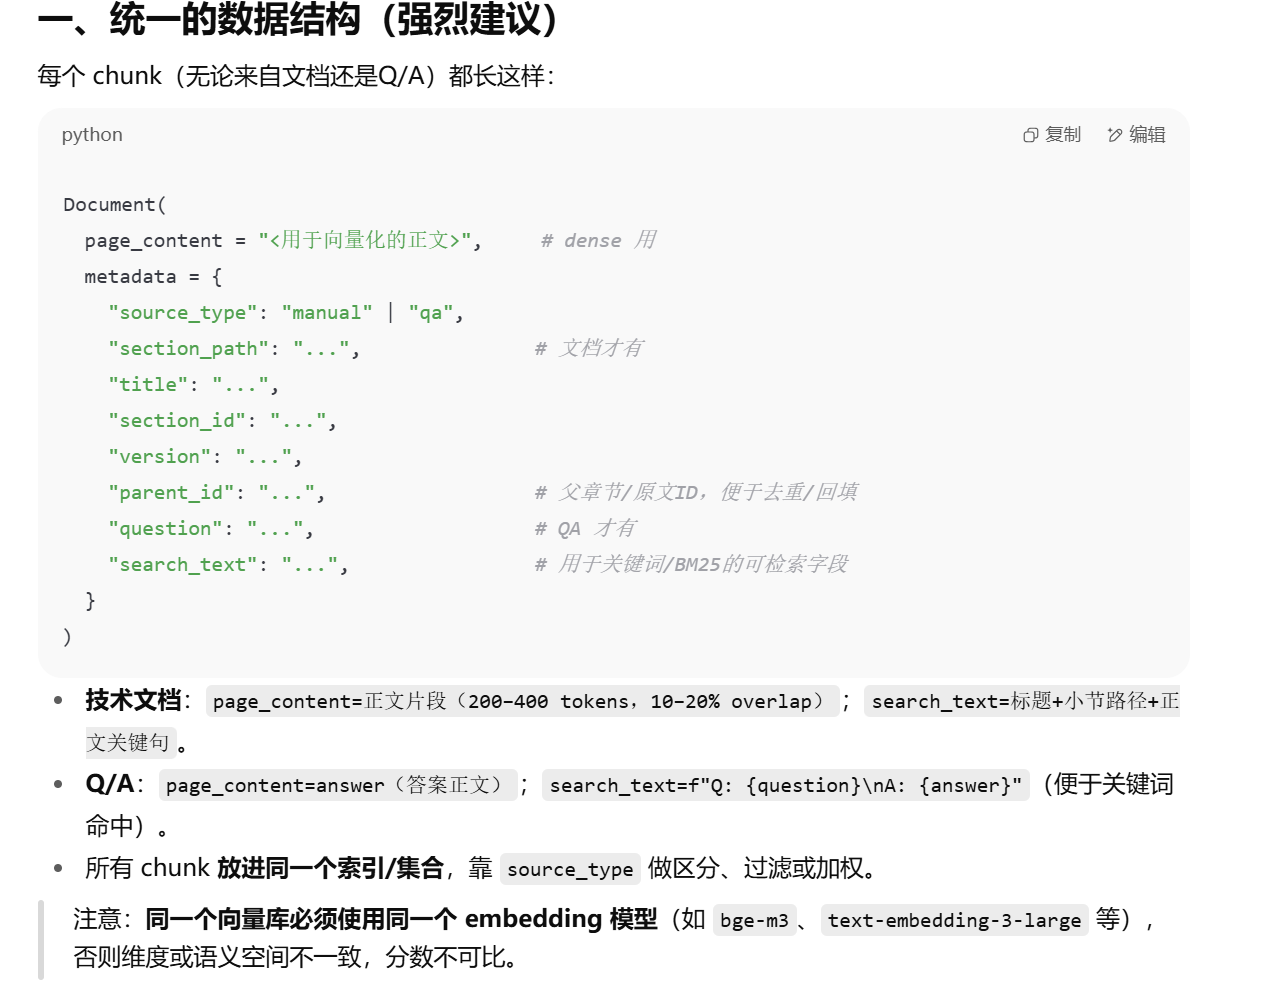

几个落地细节与常见坑

同库同模：同一向量库内必须用同一 embedding 模型与维度；否则请分库。

父子合并：检索到小块后，根据 parent_id 做去重/合并，再回填更完整的上文（ParentDocument 模式），可读性会更好。

多向量表示（进阶）：想同时索引“标题向量、正文向量”，在 FAISS 里可用“重复文档 + 不同 field 标记”的方式实现，多插两条（同 parent_id，不同 field="title/body"），检索后按 parent_id 去重。

关键词索引持久化：内存 BM25 适合原型；生产建议用 Elasticsearch / OpenSearch / Vespa / Qdrant(带文本索引) 等，search_text 字段直接建全文索引即可。

评估与参数：先把混合检索与 RRF 跑通，再考虑交叉重排；离线用 Recall@k / nDCG 做快速对比。

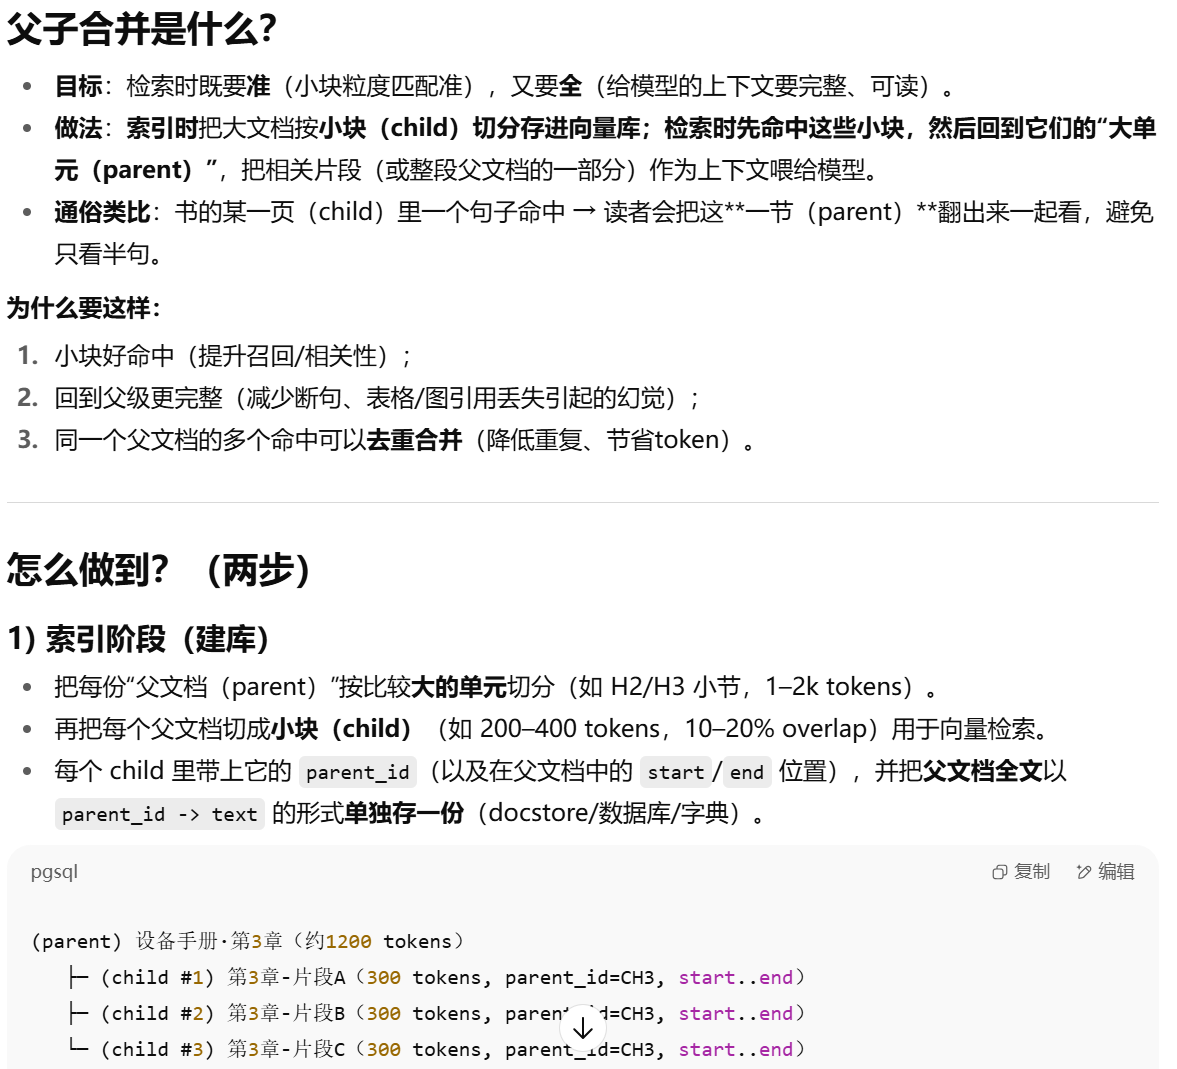

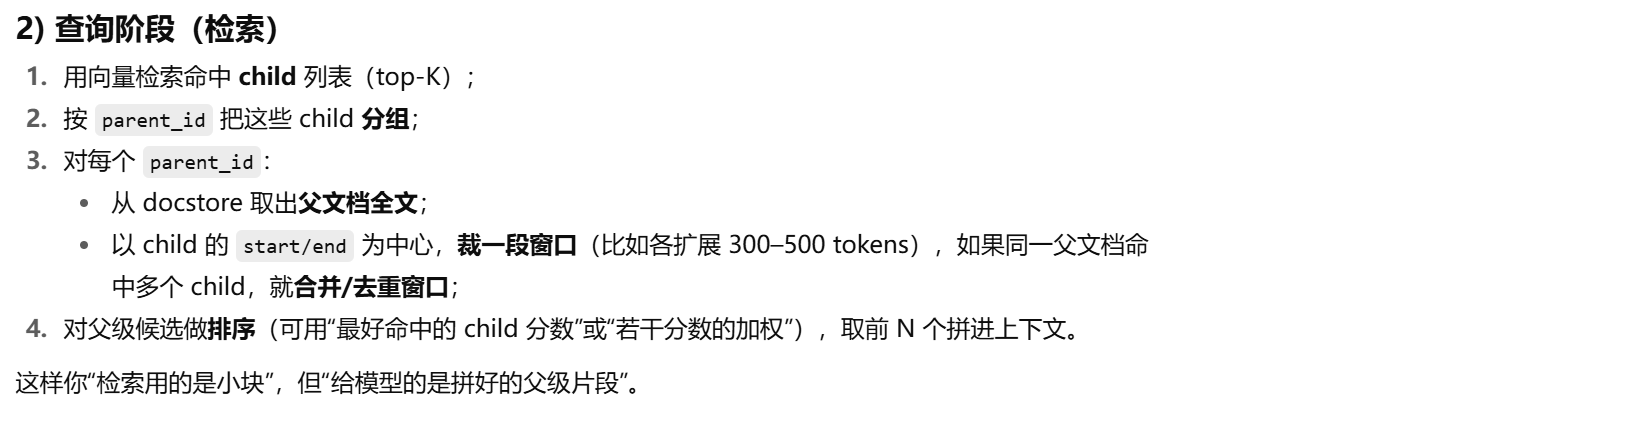

最简可用方案 A：用 LangChain 的 ParentDocumentRetriever

LangChain 会帮你把 parent↔child 的关系与回填搞定。

父子合并= “以小块来找，以大段来读”。

索引时给每个 child 记好 parent_id（和偏移），查询时把命中的 child 聚合回父文档，对父文档裁剪合并后再给模型，这样既精准又不丢上下文。

选择切分长度需要考虑的因素：

业务情况（对语意的需求），大模型的能力（模型上下文长度的限制，是否支持重叠召回），检索的精度，上下文的长度。

4. **文档向量化。**初始化向量化工具，使用阿里的DashScope API，把文本块转成向量。

In [9]:
embedding=DashScopeEmbeddings(dashscope_api_key=api_key)

#一个“向量化模型的接口对象”，也就是负责把文本转成 embedding 向量的工具。是DashScopeEmbeddings的实例对象。
#使用通义千问云端向量模型的初始向量化工具，代替了手写embedding模型名称和放入文本text的过程。

把企业知识库存到向量数据库里。

向量数据库：Faiss--本地小型项目足够。chorma,pinecone使用服务器可以用。

衡量向量之间的语意空间位置-相似度检索：

比如我现在有一个问题，我在整个大的文档之间有若干个问题。我会将自己的问题，去和这若干个问题进行相似度检索。

我们用什么样的向量化的模型，embedding的维度就是确定好的。

维向量表明：我可以从多个维度来描述这个句子的属性值和含义。

一般使用512-768维，可以帮我们干很多东西，要根据业务场景选择。

但是单纯从语意方面去做的话，会有问题，所以很多时候要加上关键词匹配。

**关键词匹配**：做元数据的过滤，因为检索不够准确，做metadata元数据，使用截巴，对提问的东西进行分词，然后匹配一下产品名称和支持库里的东西是否一致。

product_docs=[
  
  Document(page_content="智能手表，支持心率检测。“，metadata={"product":"智能手表”}），
  
  Document(page_content="蓝牙耳机，降噪功能强大。“，metadata={"product":"蓝牙耳机”}）
  
  ]

构造两条“知识文档”，准备喂给检索/向量库用的。每条文档都有两部分：

page_content：真正要被向量化（embedding）的文本内容（语义检索看的就是它）。

metadata：结构化附加信息（不参与向量化，但可用于过滤/打分/显示，比如只检索“蓝牙耳机”类目）。

第1条文档内容是“智能手表，支持心率检测。”，并打了元数据标签 product=智能手表。

之后通常会：

用 embedding 模型把 page_content 向量化，写入向量库（Faiss/Milvus/Pinecone）。

同时把同样的文本写入关键词/倒排索引（BM25/ES/SPLADE）。

查询时分别跑语义检索和关键词检索，再加权融合结果；或先用关键词过滤再做语义重排；或相反。

仅有上面这段列表代码并不会自动实现关键词匹配，必须额外建稀疏索引或使用带 BM25 的检索器。

目前只是在内存里创建了两个 Document 对象，还没有“建索引”。要让“语义 + 关键词”都生效，还需要分别建立向量索引（dense）和关键词索引（sparse/BM25），并在检索时融合它们的结果（Hybrid/Ensemble Retrieval）。

为什么“语义 + 关键词”要一起上

语义检索（dense）：能找“意思相近但不一定同词”的内容（如“心率监测”≈“心跳检测”）。

关键词检索（sparse/BM25）：能严格命中专有词/品牌词/缩写（如“ANC”“蓝牙5.3”“WH-1000XM5”），避免纯语义的漏检。

两者结合：覆盖率（Recall）与准确率（Precision）都会更稳。

metadata 在 Dense 检索里可作为过滤条件（如只搜某类目/品牌/价格段）。

BM25 默认基于词项匹配；中文要注意分词（可以换用 ES + IK、jieba 分词版 BM25，或使用 SPLADE 等稀疏向量方法）。

weights 决定“关键词 vs 语义”的相对影响力。以召回为主可加大 BM25 权重；以语义相关为主可加大 Dense 权重。

还可在融合后再加一层 Cross-Encoder 重排（reranker）进一步提升排序质量。

**为什么在 RAG 里通常不会只存“纯文本”，而是存 文本 + 元数据？**

1. 元数据作为 过滤条件

仅用文本检索时，模型只能凭语义匹配，但很多业务需要更明确的筛选条件：

只看「蓝牙耳机」类别的商品

只查「2023年之后」的技术文档

只用「某部门」上传的资料

这时，元数据可以用来 精确过滤，避免无关内容被召回。

👉 例子：

metadata={"product":"蓝牙耳机","year":2024,"source":"产品手册"}


查询时可以加条件：
filter={"product":"蓝牙耳机", "year": {"$gte": 2023}}

2. 元数据方便 混合检索（语义 + 关键词）

语义向量主要捕捉“意思”，但对专有名词、型号、SKU 可能不够敏感。

元数据字段往往就是这些“结构化标签”（品牌、型号、编号）。

这样可以把 dense 检索结果 和 metadata 过滤/关键词检索 结合起来，保证既智能又精准。

👉 例子：
用户问：
「有没有支持心率检测的智能手表？」

语义检索：找到“支持心率检测”相关文档。

metadata 过滤：限定 product="智能手表"，避免耳机等无关产品。

总结：

文本 → 负责“语义匹配”（内容相关性）。

元数据 → 负责“结构化约束”（类别、时间、来源、权限等）。

**5. 把文本转化成的向量存入向量数据库里面。**



FAISS负责做“相似度检索”，快速查找与用户提问最接近的内容块。它是一个被广泛使用的向量解锁引擎。速度比较快，而且开源免费。

通过from_documents()创建了一个Faiss数据库，然后把所有的文本块存进去。

document是我们切分后的结果，embedding是向量化工具。

documents会先被embedding工具转成向量存入里面，然后用户问问题的时候，它也会转成向量和FAISS里面所有的向量进行相似度匹配，找出最相关的几段知识。

In [10]:
db=FAISS.from_documents(documents,embedding)
#原始代码需要十几行

**6. 创建RAG问答链。**

问答链是把我们怎么去做检索，以及大模型组合起来的一个标准化的链路。这个链路就是langchain里面的chain。

因为langchain提供了chain的封装，所以我们不用写拼接的代码，直接用线程的RAG命令就能快速搭建一个问答系统。

RetrievalQA就是langchain内置的RAG实现。

先用FAISS检索最相关的文本块，然后喂给大模型（qwen-turbo）生成最终答案。

chain_type='stuff'是最简单的方法，比如说我查询出来3段的知识，我直接把它拼成一个大的文本，然后直接塞给大模型去做这个生成的回答。

retriever=db.as_retriever()这一步是直接把FAISS向量数据库变成解锁器，直接用它来查找提供最相似的知识片段。

In [11]:
qa=RetrievalQA.from_chain_type(
    llm=llm,#大语言模型
    chain_type="stuff",#简单的RAG模式，把检索到的文档直接拼接起来。
    retriever=db.as_retriever()#检索器，负责查找相似知识块。
)

1， RetrievalQA

它是 LangChain 里封装好的一个「问答链」类。

逻辑是：用户提问 → retriever 从向量数据库里找到相关文档 → 把文档交给 LLM → LLM 生成最终答案。


2， chain_type="stuff"

表示使用 最简单的问答链方式。

stuff 模式：直接把检索到的所有文档片段拼接起来（concat），作为上下文一次性传给 LLM。

优点：实现简单，适合短文本。

缺点：如果检索结果太多、上下文太长，会超出模型上下文窗口，还可能引入冗余噪音。

retriever=db.as_retriever()

db 是你的向量数据库对象。

.as_retriever() 把数据库封装成一个 retriever（检索器），用于相似度搜索，返回和问题最相关的文档。

这个 qa 是一个 RetrievalQA 问答链，采用 stuff 模式。
流程是：

用户提问

检索器找到相关文档

把文档原封不动拼接后交给 LLM

LLM 在拼接的上下文里生成答案

也就是说，这是一种 “检索-拼接-生成” 的问答链。

| chain\_type     | 工作方式                      | 优点                   | 局限                     | 典型场景               | 代价/时延 | 幻觉/跑题风险        |
| --------------- | ------------------------- | -------------------- | ---------------------- | ------------------ | ----- | -------------- |
| **stuff**       | 把检索到的 k 个块直接拼接给 LLM       | 最简单、最快；问得准时很稳        | 容量受上下文窗口限制；混杂多块易噪声     | 问题很聚焦、能用 1–3 个短块回答 | 低     | 取决于检索质量，k 大时上升 |
| **map\_reduce** | 对每块先独立回答（map），再汇总（reduce） | 覆盖面广、适合长文档；可做“多证据合成” | 成本与延迟较高；reduce 质量依赖提示词 | 跨章节汇总、对比、长篇材料总结    | 中-高   | 低-中（证据覆盖好时更低）  |
| **refine**      | 先用首块起草，再逐块增量“精修”答案        | 叙事连贯、适合“逐步补充细节”      | 顺序敏感；早期偏差可能被放大         | 教程/报告类问答、长文叙述问题    | 中     | 中              |
| **map\_rerank** | 每块给出答案+置信度，选最高分           | 自动“只取最好的一块”，精准定位证据   | 需要模型能稳定给分；覆盖多证据时不如 MR  | “就找最相关的那一格/那段”     | 中     | 低（选对单块时很稳）     |


**retriever（检索器）**是用来从知识库（通常是向量数据库，比如 FAISS、Chroma等）里查找和用户问题最相似的知识片段的组件。它的作用是 接收用户的 query → 计算向量表示 → 在向量库里做相似度检索 → 返回相关文档。

这里 db 是一个向量数据库（FAISS），.as_retriever() 会把它包装成 LangChain 的 统一检索接口。

retriever 并不只有一种。主要有几类：

向量检索器（最常见）

基于 embedding（语义向量）的相似度检索。

库：FAISS、Chroma、Milvus、Pinecone、Weaviate 等。

优点：语义检索效果好，可以找到表达方式不同但语义相近的内容。

关键词/符号检索器

基于关键字匹配或倒排索引（比如 Elasticsearch、Whoosh）。

优点：速度快、结果可解释，适合结构化文本。

缺点：无法处理同义词、语义近似。

混合检索器（Hybrid Retriever）

同时用向量相似度 + 关键词 BM25 排序，然后融合结果。

优点：兼顾语义和精确匹配，在实际场景下效果更稳健。

多路检索（Multi-Vector / Ensemble Retriever）

同时用多个向量模型（例如通用 embedding + 专业领域 embedding），再合并结果。

或者用多个检索器（向量 + 关键词），最后排序融合。

上下文增强检索（Contextual / Self-query Retriever）

检索器本身用 LLM 来分析 query，自动生成检索条件（比如根据 metadata 过滤）。

常见于 LangChain 的 SelfQueryRetriever。

特殊检索器

时间加权（Time-weighted Retriever）：优先返回最近的知识。

Memory Retriever：结合对话历史的检索。

Parent-Child Retriever：先取大 chunk，再根据子 chunk 提供更精细内容。

RAG检索器retriever类型对比

| 类型                | 工作原理                            | 代表实现（LangChain）                                              | 适用场景                  | 优点                       | 局限                     | 关键参数建议                                                           | 针对铁路技术文档的建议                                              |
| ----------------- | ------------------------------- | ------------------------------------------------------------ | --------------------- | ------------------------ | ---------------------- | ---------------------------------------------------------------- | -------------------------------------------------------- |
| 向量检索（语义检索）        | 将文本与查询编码为向量，用相似度（cosine/L2）召回   | `vectorstore.as_retriever()`（FAISS/Chroma/Milvus/Pinecone 等） | 教程/规程、问答、同义改写较多       | 语义召回强，能跨措辞匹配             | 对专有名词、编号、精确字段不敏感；易召回冗余 | `k=3~8`；`score_threshold`；良好切块（`chunk_size 500~1200`/重叠`50~150`） | 作为**主检索**；embedding 选多语言/技术文本友好模型；对“故障编号/零件号”单靠语义会丢失，需混合 |
| 关键词/BM25 检索       | 倒排索引，按词项匹配与权重排序                 | `BM25Retriever()`、Elasticsearch retriever                    | 规范编号、术语、零件号、表格字段查询    | 精确、可解释，对短精确查询特别稳         | 同义表达弱；长问句效果一般          | `k=10~50`；中文需分词；停用词表                                             | 用于**补强编号/术语检索**（如“GJ-12 螺栓扭矩”）；可与向量做融合                   |
| 混合检索（Hybrid）      | 向量 + BM25 结果融合（加权/学习排序）         | `EnsembleRetriever([vec, bm25], weights=[0.6,0.4])`          | 兼顾语义与精确匹配的综合场景        | 稳定、鲁棒，对工业语料综合表现最好        | 需要融合策略；可能略慢            | 权重从 0.5/0.5 起调；最终看离线评测                                           | **首选方案**：铁路文档往往既有规范编号又有长段经验描述                            |
| 自查询检索（Self-Query） | LLM解析查询→自动生成过滤条件（按`metadata`检索） | `SelfQueryRetriever`                                         | 有完善元数据（设备类型、线路、日期、版本） | 能自动用“线路=沪宁”“时间>2023”等过滤  | 依赖元数据质量；LLM 费用/时延      | 设计好 `metadata` schema；限制可用过滤器                                    | 为知识分域（线路、车型、部件）**强烈推荐**；能显著降低噪声                          |
| Parent-Child（父子块） | 先以较大父块召回，再返回命中的细粒度子块            | `ParentDocumentRetriever`                                    | 文档长、层次清晰（手册、规程、事故报告）  | 兼顾上下文与精细片段，减少截断          | 需预处理父子关系；构建成本高         | 父块 1–2k tokens；子块 200–500 tokens                                 | 适合“手册/长报告”，回答更完整，减少“断章取义”                                |
| 多向量/多表示检索         | 为同文档存多表示（摘要/标题/实体）并联合召回         | `MultiVectorRetriever`                                       | 查询风格多样、标题/摘要很关键       | 提升召回覆盖，防 query–doc 表达不对齐 | 索引更大，构建更复杂             | 给每文档生成摘要/关键词向量                                                   | 对“事故要点/结论”查询很有用                                          |
| 时间加权检索            | 在排序中增加时间衰减或新近性权重                | `TimeWeightedVectorStoreRetriever`                           | 工程变更、最新技术通告           | 最新优先，减少过时答案              | 旧但权威信息可能被压低            | 设置衰减半衰期（如 30–90 天）                                               | 对“最新通告/工改”很有价值；对“稳定规程”不必加权                               |
| 记忆/对话增强检索         | 将对话历史或用户画像纳入检索                  | `ConversationBufferMemory` + retriever                       | 反复追问、迭代澄清             | 连贯对话体验                   | 可能放大上下文噪声              | 限制历史长度；结合裁剪                                                      | 训练/答疑场景友好，但别让历史盖过权威文档                                    |


**7. 用户提问**



In [12]:
query="我不能吃淀粉，给我一些我能吃的菜？"

**8. 调用qa链：先检索，再生成**

qa链是用户的问题进行检索，再给到LLM进行一个生成。

In [13]:
result=qa.invoke({'query':query})

代码的功能：在这里通过检索之后，大模型会针对检索后的内容做一个生成。

.invoke()里面集成了两个任务，一个是检索，一个是生成。

这个问题先会被embedding模型转成向量，再用FAISS检索出做相关的知识片段。

比如说库里面和不含淀粉相关的段落会被检索出来，再把检索后的片段和用户问题一起打包给大模型，最终打印出答案。

.invoke() 是 LangChain 统一的调用接口，相当于把输入字典送进链里运行。
传入的 {'query': query} 意思是：告诉链「用户的问题是 query 这段文本」。
之所以写成字典，是因为链的输入是一个命名字段（这里叫 "query"），而不是纯文本。

返回值 result 是一个 字典 (dict)，里面不仅包含生成的答案，还可能包含中间信息（比如检索到的文档片段，链的 metadata）。

**9. 打印最终回答**

In [14]:
print(result["result"])

如果你不能吃淀粉，可以食用不含淀粉的蔬菜，例如：

- 洋蓟
- 芦笋
- 西蓝花
- 刺棘蓟
- 花椰菜
- 芹菜
- 小茴香
- 仙人掌
- 食用大黄（只有茎可食用）
- 南瓜花
- 海洋蔬菜
- 青海苔
- 墨角藻
- 卡罗拉
- 翅菜
- 红藻
- 羊栖菜
- 江蓠

这些蔬菜通常不含淀粉，适合你的饮食需求。


因为 result 是字典，你要取里面的 "result" 键值。

# **rag性能指标**

|                |  预测：正面（正确） |   预测：负面（不正确） |
| -------------- | ---------: | -----------: |
| **真实：正面（正确）**  | **TP**（命中） |   **FN**（漏掉） |
| **真实：负面（不正确）** | **FP**（误判） | **TN**（判对为负） |


| 指标          | 英文        | 公式                      | 直觉解释（以“预测正确”为正类）                       |
| ----------- | --------- | ----------------------- | -------------------------------------- |
| **准确率**     | Accuracy  | (TP+TN) / (TP+FP+FN+TN) | **总体有多准**。类别很不平衡时可能“看起来很高”。            |
| **精确率**     | Precision | TP / (TP+FP)            | 预测为“正确”的里面，**有多少真正确**。减少“胡乱说对”的倾向。     |
| **召回率**     | Recall    | TP / (TP+FN)            | 真实“正确”的里面，**被你找回了多少**。减少漏判。            |
| **F1 分数**   | F1-score  | 2×(P×R)/(P+R)           | **Precision 与 Recall 的调和平均**，二者失衡时更公平。 |
| **Support** | Support   | 该类真实样本数                 | 每个类别在测试集中**真实出现了多少个样本**。               |


做RAG的时候，要看答案准不准确。

主要看召回率和精准度两个指标

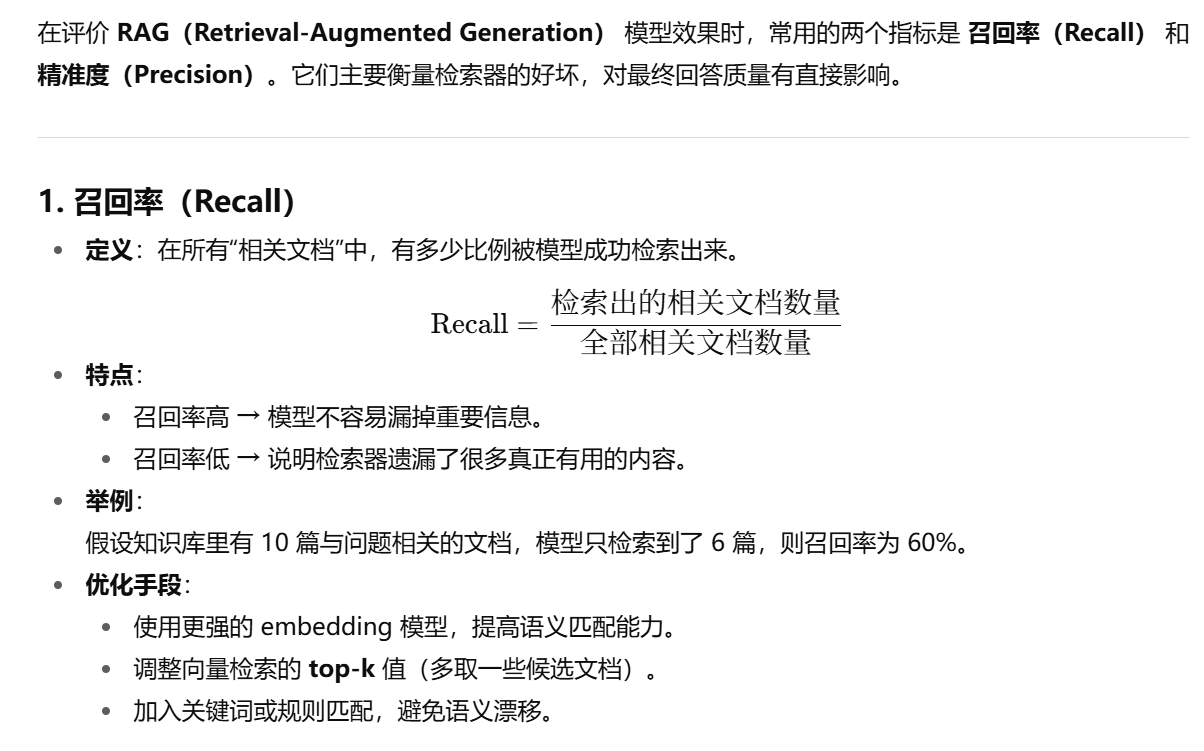

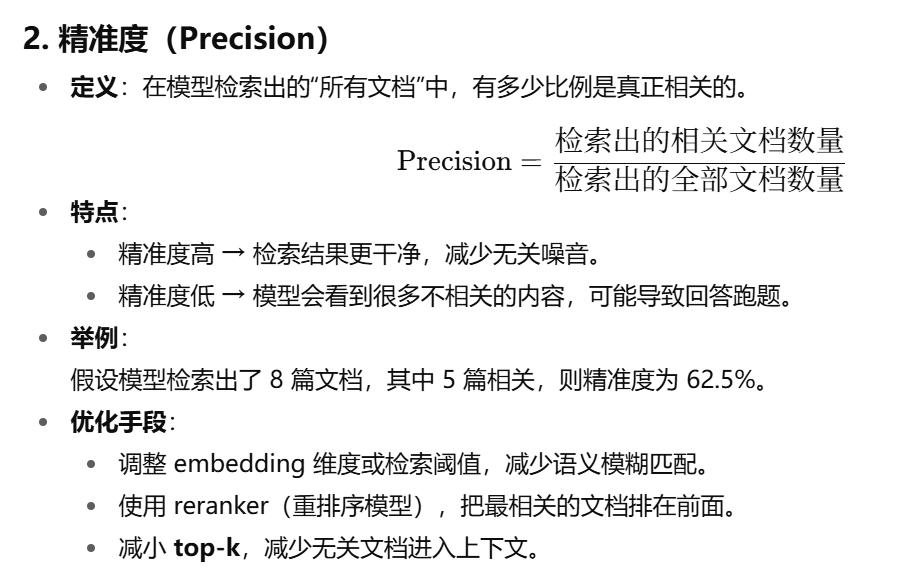

✅ 总结：

召回率强调“不遗漏” → 保证相关文档都找得到。

精准度强调“少干扰” → 保证返回的文档大部分有用。

在实际 RAG 系统里，通常需要在两者之间 权衡：

培训/知识库查询类系统 → 更关注 召回率（宁可多取一些，也不要漏掉关键信息）。

对话问答/搜索类系统 → 更关注 精准度（减少噪音，保证回答专注）。

**1. 检索阶段**

| 指标                            | 含义                               | 优化手段                                                                                                                  |
| ----------------------------- | -------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **Recall\@k（召回率）**            | 前 k 个检索结果中包含多少比例的相关文档。越高说明覆盖面越好。 | - 使用更强的 embedding 模型（如 OpenAI `text-embedding-3-large`，BGE 等）<br>- 增大 k 值（如从 top-5 → top-10）<br>- 改进文档切分策略（避免切块太碎或太大） |
| **Precision\@k（准确率）**         | 前 k 个检索结果中，相关文档占比。越高说明检索更精准。     | - 优化 embedding 模型（fine-tune 在领域语料上）<br>- 结合 BM25/关键词过滤 + 向量检索（Hybrid Search）<br>- 调整 chunk overlap，减少无关信息             |
| **MRR（Mean Reciprocal Rank）** | 衡量第一个相关文档出现的位置，越靠前越好。            | - 改进向量相似度计算方式（cosine / dot-product）<br>- 用 reranker 模型（如 BERT-based cross-encoder）重排结果                                |
| **nDCG\@k（归一化折扣累积增益）**        | 衡量检索结果的排序质量，相关度高的文档排前面得分更高。      | - 加入 reranker 阶段（Dense + Cross-Encoder）<br>- 针对领域数据微调 embedding 模型                                                    |


**2. 生成阶段**

| 指标                        | 含义                          | 优化手段                                                                                |
| ------------------------- | --------------------------- | ----------------------------------------------------------------------------------- |
| **Exact Match (EM)**      | 生成答案是否与标准答案完全一致。            | - 提示工程（Prompt Engineering）优化<br>- 加强知识覆盖的检索 recall<br>- 采用 instruction-tuned LLM    |
| **F1 Score**              | 衡量生成答案对参考答案的覆盖率（兼顾精确率和召回率）。 | - 优化 chunk 切分，保证关键信息可检索到<br>- 使用多轮检索（iterative retrieval）                           |
| **ROUGE / BLEU**          | 生成文本和参考答案的 n-gram 重叠率。      | - 适合有标准答案的 QA 数据集<br>- 优化 LLM 的指令对齐能力                                               |
| **Faithfulness（忠实性）**     | 生成内容是否基于检索到的文档，避免“幻觉”。      | - 在 Prompt 中强制 LLM “只使用给定上下文”<br>- 使用 groundedness 检查器或判别模型<br>- Reranker 保证输入文档相关性 |
| **Answer Relevance（相关性）** | 答案是否紧扣用户提问。                 | - 在 Prompt 中明确要求“回答问题而非总结文档”<br>- 使用 QA 微调模型                                        |


**3. 系统指标**

| 指标                      | 含义              | 优化手段                                                                                          |
| ----------------------- | --------------- | --------------------------------------------------------------------------------------------- |
| **Latency（延迟）**         | 从用户提问到回答的总响应时间。 | - 向量库选用高效 ANN 索引（Faiss / Milvus / Pinecone）<br>- 缓存常见问题 embedding<br>- 降低 k 值，减少传入 LLM 的上下文长度 |
| **Throughput（吞吐量）**     | 系统每秒能处理多少请求。    | - 使用批量查询（batch embedding + batch retrieval）<br>- 模型并行或量化（如 8-bit/4-bit）<br>- 使用轻量化 LLM        |
| **成本（Cost Efficiency）** | 每条查询的计算/调用费用。   | - 压缩 embedding 维度（如 1024 → 384）<br>- 用混合索引（关键词 + 向量）减少 LLM 调用<br>- 缓存常见问题答案                   |


语义对齐：向量空间的几何关系 是否等于 语义关系一致。

更好的embedding模型需要语义对齐能力更强，工程效率更好：在相同或更低延迟/内存占用下提供相当或更好的效果（支撑量化、蒸馏等），robust跨语言等。

# **和原生代码的区别**

文本转embedding：

In [ ]:
def get_embedding(self,text_list):
  """
  text_list:文本列表
  return:向量列表
  """
  for text in text_list:
    response = dashscope.TextEmbedding.call(
        model="text-embedding-v1",
        input=text
    )
    if response.status_code == 200:
      embeddings.append(response.output['embedding'][0]['embedding'])
  return np.array(embedding)

构建prompt

In [ ]:
prompt=ai_helper.build_prompt(query=query,context=context)

但是langchain里面只需要用RetrievalQA就行。

# **分块**

rag分块，chunking技术。

为什么要rag分块：

1. 如果不分块，太长的文档无法直接生成embedding，因为大多数文本嵌入模型都对输入文本长度有严格限制。

2. 如果块太大会混杂多个主题，适当分块会使得语意集中，检索出的块的相关性高。

3. 降低生成负担。过大的文档会占用大量token，还会降低模型对真正相关信息的关注度。

在检索时，把一整个文本从头读到尾，和，把文本分成3块，排除其中2块后将剩下的1块从头读到尾的时间是不一样的。

**常用开源/可本地部署的文本嵌入模型的“单次输入最大长度（token 上限）：**

| 模型                                           |                最大输入长度（tokens） | 备注                                                                                    | 主要来源 |
| -------------------------------------------- | ----------------------------: | ------------------------------------------------------------------------------------- | ---- |
| **Meta Llama 3.1 (8B/70B/405B，LLM 用作池化取向量)** |                   **128,000** | 非专用“embedding 模型”，若用均值/CLS 池化取向量，则继承其 128K 上下文窗口。适合超长文本分块后聚合。 ([Hugging Face][1])     |      |
| **Qwen3-Embedding-8B**                       |                    **32,768** | 模型卡写明“Context Length: 32k”；系列 0.6B/4B/8B 均为 32k。 ([Hugging Face][2])                  |      |
| **BAAI/bge-m3**                              |                     **8,192** | 支持 dense + multi-vector + sparse 一体；模型卡与示例代码均使用 8192。 ([Hugging Face][3])             |      |
| **Alibaba-NLP / GTE-large-en-v1.5**          |                     **8,192** | GTE v1.5 系列将上下文扩到 8192。 ([Hugging Face][4])                                           |      |
| **intfloat/e5-mistral-7b-instruct**          |               **4,096（推荐上限）** | 模型卡明确“不推荐超过 4096 tokens”。 ([Hugging Face][5])                                         |      |
| **intfloat/e5-large-v2**                     |                       **512** | 超过会被截断到 512。 ([Hugging Face][6], [SambaNova 文档][7])                                   |      |
| **sentence-transformers / all-MiniLM-L6-v2** |                 **256（常见截断）** | 训练时长度 128；不少 ST 配置默认把输入截到 256。 ([Hugging Face][15])                                   |      |


**RAG常见文本分块策略**

| 策略                         | 核心做法                        | 适用场景            | 优点             | 风险/缺点         | 常用参数/经验                                    | 关键来源                                                                    |
| -------------------------- | --------------------------- | --------------- | -------------- | ------------- | ------------------------------------------ | ----------------------------------------------------------------------- |
| 固定大小（按字/词/Token）           | 直接按长度切块，可设置重叠               | 一般文本、快速上线       | 实现最简单、速度快      | 可能切断语义单元      | 200–400 词或 500–1k tokens；15–30% 重叠         | Pinecone 概述与实践。 ([Pinecone][1])                                         |
| 递归优先边界（Recursive Splitter） | 先按段/句/行等较“自然”的边界切，超长再细分     | 手册/报告/博客等层次清晰文本 | 尽量保留自然语义单元     | 仍可能在异常格式文本上失效 | 300–800 tokens，10–25% 重叠                   | LangChain 文档；LlamaIndex 基础策略。 ([LangChain][2], [docs.llamaindex.ai][3]) |
| 滑动窗口/重叠窗口                  | 相邻块按一定窗口重叠，保留跨块上下文          | 叙述连贯文本、FAQ、知识库  | 降低“句子被切断”的信息丢失 | 索引量增大、召回重复    | 重叠占比 20–50%；Weaviate 给出基线 100–200 词、50 词重叠 | Weaviate 指南。 ([docs.weaviate.io][4])                                    |
| 句窗（n‑sentence window）      | 以句为单位，按 n 句组成块，可叠加滑窗        | 论文段落、技术文档       | 语义单元清晰         | 句长差异带来不均匀     | n=3–8；可配 1–3 句重叠                           | 社区与教程综述。 ([stackoverflow.blog][5], [IBM][6])                            |
| 语义分块（Semantic Chunking）    | 用嵌入相似度选断点，使每块内部主题一致         | 主题切换频繁/长文档      | 语义连贯、检索相关性更高   | 预处理成本 ↑       | 目标块 200–800 tokens；阈值依相似度分布调               | LlamaIndex 语义分块示例；多源综述。 ([docs.llamaindex.ai][7], [multimodal.dev][8])  |
| 版面/结构感知（Layout‑aware）      | 基于标题层级、段落、列表、页眉脚、图表位置切分     | PDF、扫描件、技术规程    | 利用文档结构提升可读性    | 需要版面分析管线      | 以“节/小节”为块；对图表另行抽取                          | Azure AI Search 文档布局技能；实践文章。 ([Microsoft Learn][9], [Medium][10])       |
| 表格感知（Table‑aware）          | 表格行/列为基本单元；附带表头与上下文         | 报表、规范附表、KPI 表   | 保存表结构语义，便于检索   | 行太长需再次拆分      | 常用：按行分块，附列名与表题                             | AWS 样例（按行并附表头）；专门实践文。 ([GitHub][11], [ragie.ai][12])                    |
| 会话感知                       | 以“若干轮对话”为块并重叠，保留说话人/时间元数据   | 客服日志、运维工单       | 维持对话连贯         | 容易重复召回        | 5–7 轮/块，2–3 轮重叠                            | Dell 技术博客建议。 ([infohub.delltechnologies.com][13])                       |
| 分层/层级分块（Hierarchical）      | 同时建立粗/细两级块：先用小块召回，再向上拼接“父块” | 需要兼顾召回与完整语境     | 召回准、上下文全       | 实现与合并逻辑更复杂    | 小块 200–400 tokens；父块 1–2k tokens           | 多源教程与社区经验。 ([stackoverflow.blog][5], [IBM][6])                          |
| **Late Chunking**          | 先以较大单元索引/检索，命中后再按需细分与拼接     | 长上下文与成本平衡       | 兼顾成本与质量        | 实现复杂、需二次处理    | 命中段再二次切分到 300–800 tokens                   | Weaviate 官方博文。 ([weaviate.io][14])                                      |
| 代码感知（AST‑based）            | 以函数/类/模块等 AST 语法单元切分，附必要依赖  | 代码库、脚本          | 片段可运行且语义自洽     | 需语言解析器        | 函数/类为块；必要时合并相关单元                           | cAST 论文；工程实践。 ([arXiv][15], [Medium][16])                               |
| 集群/主题分块（Cluster‑based）     | 句子/段落先嵌入聚类，再按簇合并成块          | 文集/多主题混排        | 主题一致性高         | 预处理重、参数多      | 目标块 500–1k tokens                          | 近期综述与实践文章。 ([agenta.ai][17])                                            |
| 元数据感知（Metadata‑aware）      | 在切分时注入/携带来源、章节、时间、作者等元数据    | 合规可追溯、排序重排      | 便于重排/过滤        | 需要一致的元数据规范    | 关键字段：标题、章节、页码、时间、表/图编号                     | 实践经验与教程。 ([Medium][18])                                                 |
| 策略                                | 核心做法                                  | 优点          | 风险/代价            | 适用场景        | 常用参数 / 要点                  | 来源                                                             |
| --------------------------------- | ------------------------------------- | ----------- | ---------------- | ----------- | -------------------------- | -------------------------------------------------------------- |
| 固定大小（字符/Token）+ 重叠                | 固定长度切分，保留少量重叠                         | 简单易用；易于批量处理 | 容易破坏语义；积累重复      | 通用文本初步实验    | 500–1000 tokens，重叠 10–20 % | ([Medium][1], [Medium][2])                                     |
| 递归/层级切分                           | 按段落→句子→词递归切分                          | 避免语义中断，灵活   | 实现麻烦，慢           | 格式化文本       | 分隔符序列 + overlap            | ([MongoDB][3], [pinecone.io][4])                               |
| 语义分块（Semantic）                    | 基于向量相似度判断断点                           | 语义一致性高      | 计算量大，参数敏感        | 长文与主题跳跃文档   | 相似度阈值 + 大小限制               | ([F22 Labs][5], [Daily Dose of Data Science][6])               |
| Document structure–based chunking | 根据文档标题、结构（如 Markdown/HTML headings）切分 | 保留章节语义；易追溯  | 需结构清晰；块长度变不均     | 技术文档、API 文档 | 结构层级、是否保留标题                | ([Daily Dose of Data Science][6], [blog.dailydoseofds.com][7]) |
| LLM-based chunking                | 使用 LLM（通过 prompt）生成语义独立的切块            | 语义准确度高      | 成本高，依赖 LLM 上下文限制 | 特殊场景、高质量需求  | Prompt 设计 + 块长度控制          | ([Daily Dose of Data Science][6])                              |


确定文本切割的最优策略：

两个参数chunk size, overlap。

chunk size会受到两个模型的限制（embedding，LLM）。

不同text splitter的优劣，如何选取。

向量数据库的两个重要特点：1.能不能存向量。2。能不能做向量检索。

In [ ]:
#创建文本分割器
text_splitter=RecursiveCharacterTextSplitter(
    separators=['\n\n','\n','.',' ',''],
    chunk_size=512,
    chunk_overlap=128,
    length_function=len,
)
#分割文本
chunks=text_splitter.split_text(text)
print("文本被分割成{len(chunks)}个块")

#然后创建知识库，存储文本对应的页码信息。
#从本地知识库loading，从磁盘加载向量数据库和页码信息。
#这样向量的存储及前面的操作就只用做一次，后面都是基于本地向量化的知识来进行检索

# **创建向量数据库**


在向量数据库里面，所有的文本都会创建它的索引，也就是会创建它的一个位置，一个下标。

存入向量数据库必须有两个操作：

1. 向量化

2. 索引构建。

In [16]:
import os
print("exists?", os.path.exists("/content/.env"))

exists? True


In [ ]:
!pip install -U langchain-community dashscope langchain faiss-cpu python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 40.4 MB/s eta 0:00:00


In [17]:
from langchain_community.embeddings import DashScopeEmbeddings
from langchain_community.vectorstores import FAISS #向量数据库
from langchain_community.chat_models import ChatTongyi #聊天模型

In [18]:
policy_texts=[
    "必须在包裹递送日期后的 7 个自然日内提出退货申请。"
    "超过 7 个自然日但商品无损坏可以申请换货"
    "保修期内可以免费维修。"
    "商品必须是原始状态，未经使用、穿戴、改动、洗涤、标记或损坏。"
    "商品必须连同所有原始包装一起退回，其中包括鞋盒、防尘袋、品牌标签和防伪卡。所有包装不得更改、损坏或被移除。"
    "特殊商品不支持退货。"
]

In [19]:
api_key=os.getenv("DASHSCOPE_API_KEY")

In [20]:
embeddings=DashScopeEmbeddings(
    model="text-embedding-v1",
    dashscope_api_key=api_key,
)

初始化embedding模型，传入API key。


In [21]:
policy_db=FAISS.from_texts(policy_texts,embeddings)
#这一行代码做了三件事：

#把 policy_texts 里的每条文本编码成向量；

#创建并填充一个 FAISS 索引（在内存中）；

#返回一个可用于检索的向量库对象 policy_db。

创建索引。把policy_texts变成embeddings存入FAISS。

In [22]:
policy_db.save_local("faiss_database")

保存向量库到本地，方便后续快速加载使用。

跑完以上代码，在文件里就会出现新的文件夹faiss_database。

这个文件夹里有index.faiss（索引）和index.pkl两个文件

这个文件是在本地磁盘上面保存的，类似于数据库的文件一样，专门存储文本和向量和对应的关系，以后如果用的是童颜的知识库，我只用加载本地的文件，本地的索引，就能去做相似度的检索。不需要再去计算向量，创建索引，直接用本地的文件就足够了。

创建索引的原始代码：

In [23]:
def create_faiss_index(self, knowledge_list):
  embeddings = self.get_embeddings(knowledge_list)
  dimension = embeddings.shape[1]
  self.faiss_index = faiss.IndexFlatL2(dimension)
  self.faiss_index.add(embeddings)
  self.knowledge_list = knowledge_list

创建FAISS索引，并将知识库向量存储进去。

把一组“知识片段”（knowledge_list，通常是一堆文本或文档对象）先变成向量（embeddings），再用 FAISS 建一个向量索引，最后把这些向量加入索引里；并把原始的知识列表保存起来，方便以后把“搜到的向量”反查回“原始文本”。

def create_faiss_index(self, knowledge_list):

输入：knowledge_list（长度为 N 的列表）。常见形式：

["文档A的文本...", "文档B的文本...", ...]

或者 [Document(page_content="..."), ...]

输出：函数本身没有 return，但会在对象上产生副作用（给 self 挂上 faiss_index 和 knowledge_list）。

1.生成向量

embeddings = self.get_embeddings(knowledge_list)

输入：knowledge_list

发生了什么：把每个知识片段编码为一个定长的实数向量（比如 384 维、768 维等）。这一步依赖你实现的 get_embeddings，它通常会：

清洗/拼接文本

调用某个嵌入模型（如 BGE、E5、text-embedding-3 等）

得到一个二维数组

输出：embeddings（形状 N x D 的二维数组/矩阵，常见是 numpy.ndarray，dtype 应为 float32）

例：(1000, 768) 表示 1000 条文本，每条 768 维向量

小提醒

FAISS 要求 float32 且内存连续。

2) 取向量维度

dimension = embeddings.shape[1]


输入：embeddings (N x D)

发生了什么：读取列数 D，也就是每个向量的维度

输出：dimension（整数 D）

3) 创建 FAISS 索引（L2 距离）

self.faiss_index = faiss.IndexFlatL2(dimension)


输入：dimension（D）

发生了什么：构造一个**精确（exact）**的“扁平索引”（Flat），相似度度量是 L2（欧氏距离）。

这是 FAISS 最基础的索引类型，不需要训练（和 IVF/HNSW 这类需要“训练/建图”的不同），添加就能用，查询是精确的，但大数据量时会慢一些。

输出/副作用：self.faiss_index 变为一个空索引，此时还没有任何向量。

4) 把向量加入索引

self.faiss_index.add(embeddings)


输入：embeddings (N x D, float32)

发生了什么：把 N 个向量一次性加入索引。

ID 分配：IndexFlatL2 会按添加顺序自动分配整数ID：第 0 条向量是 ID=0，第 1 条是 ID=1，…

输出/副作用：索引里现在有 N 条向量，可以被搜索了（search）。

5) 保存原始知识列表（用于回查）

self.knowledge_list = knowledge_list


输入：knowledge_list

发生了什么：把原始文本列表挂到对象上。

以后你做相似搜索得到一串 向量ID，可以用这些 ID 当作列表下标，回到原文：self.knowledge_list[i]。

输出/副作用：对象记住了原始知识库内容，方便“向量ID → 原文”的映射。

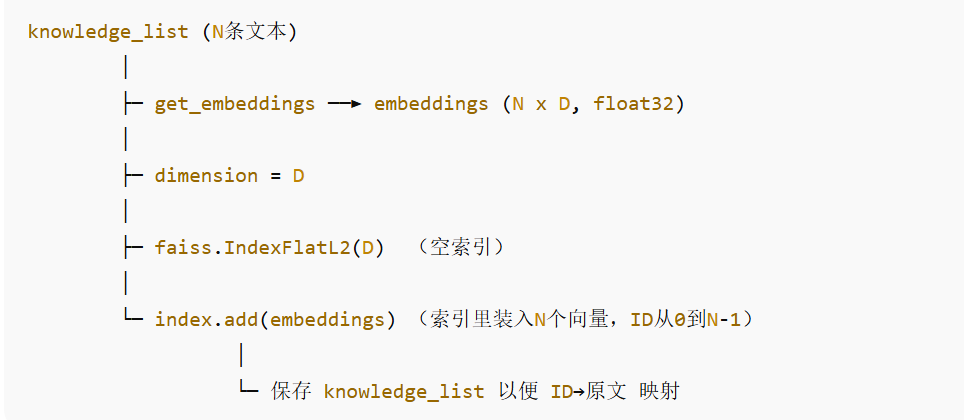

1. 为什么参数是“向量的列数”（dimension）？

在向量检索里，每条数据都是一个 D 维向量（如 [0.12, -0.98, ...]）。

FAISS 在创建索引的时候，必须知道：我存进去的向量是多少维的。

这样它才能在内部开好一块存储空间，并在做距离计算时知道要“对多少个维度做加减乘除”。

faiss.IndexFlatL2(dimension) 会返回一个 IndexFlatL2 对象，这是 FAISS 提供的最简单的一种索引。

特点：

“Flat” 表示不做压缩、不做近似，所有向量都会完整存储。

“L2” 表示内部默认的相似度度量方式是 L2 距离（欧氏距离）。

此时的索引是空的，相当于开了一个“空箱子”，只能装符合 dimension 维度的向量。

2. 为什么此时要有相似度度量？

向量索引的作用就是：以后给你一个“查询向量”，你能告诉我库里最相似的几个向量。

“相似”必须有一个衡量标准，不然计算机根本不知道什么叫“近、远”。

L2 距离：看两点的欧氏距离，越小越相似。

所以在创建索引的时候，必须明确告诉 FAISS：

“我以后查询时要用 L2 距离来衡量相似度。”

否则它没法在内部准备好对应的计算逻辑。

4. 没有相似度度量就不能创建索引了吗？

是的，不能。

FAISS 的每种索引类型都绑定了一个“距离/相似度定义”。

如果没有这个定义，FAISS 就不知道怎么回答 “给我最相似的 5 条” 这种查询。

你可以换别的索引类型（例如 IndexFlatIP、IndexHNSWFlat、IndexIVFPQ），但是每个索引类型都要求你指定维度，而且内部都内置了一种距离度量。

# **检索**

1. 用户输入（提问）：企业知识
2. **检索：把用户问题变成向量，去知识库检索最相关的文档**
3. 构造prompt：把上面的文档拼接上提示词，发给大模型。
4. 大模型生成：降低幻觉。（不能100%杜绝）

**如何加速向量检索（会有知识库里有上亿条向量的情况）？**

1. ANN算法，近似最近邻。kNN的加速版，简化但是精细度降低版。

2. 量化压缩。embedding里16位小数可以压缩成8位小数。

传统的最近邻（kNN）搜索需要在向量库里逐个计算相似度（例如余弦相似度、欧氏距离），复杂度大约是 O(N)，当向量库里有上百万甚至上亿条向量时，这种线性扫描非常慢。

ANN 算法的核心思想是：放弃精确最近邻，允许一定的近似误差，以换取巨大的速度提升。通过构建向量索引，将相似度高的向量，在向量空间中尽可能靠近，从而加速“近似最近邻搜索。”

ANN算法会面对不可能三角：速度，准确性，内存。

最常用方法：HNSM层级化可导航小世界。倒排索引。

ANN基于data structure的算法:

1. Hash_based: LSH

Tree_based: ANNOY

Graph_based:HNSW

Cluster-based: IVF

ANN基于压缩compression的算法：

1. SQ

2. PQ

1. LSH（Locality-Sensitive Hashing）

基本流程：

选定一组哈希函数，使得“相似向量”很可能映射到同一桶中。

将数据向量用这些函数哈希，分配到不同的桶里。

查询时，对查询向量哈希，提取对应桶里所有候选项，再从中筛选近邻。

2. Annoy（Approximate Nearest Neighbors Oh Yeah）

处理流程：

构建阶段：通过随机生成的超平面，对向量空间递归划分。

随机选择两个数据点，依据这两个点间的中间超平面将数据空间一分为二，然后对子空间再次进行划分。递归进行，直到满足树的深度或节点数据量要求，生成一棵树。重复多次，构建多个独立的随机投影树（forest）。

查询阶段：将查询向量分别在每棵树中走到叶节点，搜集各树的候选向量，再集中排序选出近邻。

3. HNSW（Hierarchical Navigable Small World）

工作机制：

构建多层图结构：顶层节点稀少，用于快速“跳转式”导航；底层节点密集，用于精细近邻搜索。

查询时从高层一个入口节点开始，在每层进行贪心搜索（在每一步，都选择当前看来“最优”的选项，即 局部最优。不回溯、不考虑全局，只是不断“往更接近目标的方向走”。）——沿着更近的边跳转，逐层深入，直至定位底层近邻。

这种层级图结构实现快速缩小搜索范围，且搜索复杂度在高维空间中仍能接近对数级，精度高、召回好，但索引构建与内存占用成本较高。

4. IVF（Inverted File / IVFFlat）

核心流程：

使用聚类算法（如 k-means）将向量空间划分成多个簇（clusters），每簇对应一个倒排列表（inverted file）。

查询时先找到与查询向量最接近的簇（或多个簇），只在这些簇中的向量中查找近邻，减少整体计算量。

常见变体包括 IVF-PQ，将向量压缩以减小索引大小并加速搜索。

这种方法依赖数据的簇结构，若聚类合理，能显著提升速度；但簇质量不好时可能影响准确性。

| 项目       | **kNN（k-Nearest Neighbors）**                                                | **k-means（k-means Clustering）**                                                                                                         |
| -------- | --------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **学习类型** | 监督学习（Supervised Learning）                                                   | 无监督学习（Unsupervised Learning）                                                                                                            |
| **输入数据** | 必须有标签（已知类别）                                                                 | 不需要标签（只用特征）                                                                                                                             |
| **核心思想** | 通过距离最近的 k 个邻居“投票”决定类别                                                       | 将数据划分为 k 个簇，再把簇映射到类别                                                                                                                    |
| **主要步骤** | 1. 存储带标签的训练数据<br>2. 输入新样本<br>3. 计算与所有训练样本的距离<br>4. 找到最近的 k 个邻居<br>5. 投票决定类别 | 1. **初始化**：随机选 k 个中心（或用 k-means++）<br>2. 将样本分配到最近的中心<br>3. 更新中心（取簇均值）<br>4. 重复分配与更新，直到收敛<br>5. 如果已知类别数=k，则把簇对应到类别<br>6. 新样本分到最近簇中心对应的类别 |
| **输出**   | 新样本的预测类别（直接分类器）                                                             | 簇标签，需进一步对应到类别（间接分类器）                                                                                                                    |
| **优点**   | 简单直观、分类效果好（尤其在局部结构明显时）                                                      | 可以发现数据的潜在结构，适合无标签数据                                                                                                                     |
| **缺点**   | 预测时计算量大（需和所有样本比距离）；对高维数据不友好                                                 | 需要预先指定 k；结果依赖初始中心；不保证和真实类别完全对应                                                                                                          |
| **典型应用** | 文本分类、图像识别、推荐系统                                                              | 客户分群、文本主题发现、作为分类前的预处理                                                                                                                   |


1. Scalar Quantization（SQ）

核心思想：逐维压缩每个向量维度，将原本 32-bit 浮点值映射为更低比特的整数（通常是 8-bit），显著减少存储空间。

压缩原理：

分析训练数据中每维的最小值和最大值。

将该范围均匀划分为 256 个桶（对应 8-bit）。

每个浮点值通过确定所属桶编号被压缩为一个字节。

优劣点评：

优点：可获得 4 倍内存压缩，压缩后召回（recall）下降仅 1–3%，压缩/查询速度快。

应用技巧：例如在 Weaviate 中，启用 SQ 后会“过量抓取”候选项，再用原始向量进行精筛，从而提高召回率。

2. Product Quantization（PQ）

核心思想：将高维向量分成多个子向量（segments），并对每个子空间独立进行量化，以高效压缩整个向量表示。

压缩流程：

将向量（例如 128 维）拆分为多个子向量（例如每段 4 维，共 32 段）。

采用类似 k-means 的方法为每个子向量训练词典（codebook），每个词典含有固定数量的中心（centroids）。

每段子向量被替换为其最近中心的索引，压缩后得到一个短码。PQ code。

优势：

能显著节省内存（最高可达 97%），速度提升多倍，且支持与 IVF 等索引结合，整体加速效果可达数十倍。

| 算法                            | 速度（Speed）                                                            | 准确性（Accuracy / Recall）                                                              | 内存消耗（Memory）                                                          |
| ----------------------------- | -------------------------------------------------------------------- | ----------------------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **LSH**                       | 非常快建索引（sublinear）；查询速度快，但需增多个哈希表或位长才能提高 recall  ([Rohan's Bytes][1]) | recall 难以保证。高 recall 需使用非常长哈希码（如 8192-bit），成本高  ([Rohan's Bytes][1], [Pinecone][2]) | 若为提高 recall 构建大量哈希表或长码，会显著增加内存占用  ([Rohan's Bytes][1], [Pinecone][2]) |
| **Annoy**                     | 构建多棵树，构建快；查询速度可调（树越多越慢）  ([TigerData][3])                            | 精度可调（树越多 accuracy 越高），但通常低于 HNSW  ([TigerData][3])                                  | 树多则占内存更多；内存效率一般  ([TigerData][3])                                     |
| **HNSW**                      | 查询非常快（近似对数级时间）  ([arXiv][4], [维基百科][5])                              | 准确性高，可达很高 recall（SOTA 级）  ([维基百科][5], [多伦多大学计算机科学系][6])                             | 内存占用高，索引大；比 IVF、PQ 消耗多  ([多伦多大学计算机科学系][6], [arXiv][7])                |
| **IVF**                       | 搜索速度快（聚类减少扫描量）  ([TiDB][8], [Milvus][9])                             | recall 中等，取决于 nprobe 参数; 少 probe 快但 recall 低  ([Milvus][10], [Medium][11])          | 聚类结构和倒排索引占内存，适中  ([TiDB][8], [arXiv][7])                              |
| **SQ** (Scalar Quantization)  | 查询速度快，压缩过程快  ([arXiv][12])                                           | 精度略有下降（通常 recall 降 1–3%），但总体保留较好  ([arXiv][12])                                     | 高压缩比（约 4× 降低内存）  ([arXiv][12])                                        |
| **PQ** (Product Quantization) | 查询速度快（短码加速）  ([TiDB][8], [Medium][11], [arXiv][12])                  | 精度略有损失；优化如 IVF-PQ 可改善，但仍低于 HNSW  ([TiDB][8], [Medium][11], [Milvus][10])            | 极高内存效率（可达 97% 降低），索引非常紧凑  ([TiDB][8], [arXiv][7])                     |

[1]: https://www.rohan-paul.com/p/vector-search-strategies-focusing?utm_source=chatgpt.com "vector search strategies, focusing on clustering and Locality ..."
[2]: https://www.pinecone.io/learn/series/faiss/vector-indexes/?utm_source=chatgpt.com "Nearest Neighbor Indexes for Similarity Search"
[3]: https://www.tigerdata.com/blog/understanding-diskann?utm_source=chatgpt.com "Understanding DiskANN"
[4]: https://arxiv.org/html/2505.11783v1?utm_source=chatgpt.com "Efficient Vector Search on Disaggregated Memory with d- ..."
[5]: https://en.wikipedia.org/wiki/Hierarchical_navigable_small_world?utm_source=chatgpt.com "Hierarchical navigable small world"
[6]: https://www.cs.toronto.edu/~mgabel/csc2233/slides/3_-_Basic_Indexing.pdf?utm_source=chatgpt.com "vector Databases"
[7]: https://arxiv.org/html/2507.21939v1?utm_source=chatgpt.com "The Curious Case of High-Dimensional Indexing as a File ..."
[8]: https://www.pingcap.com/article/approximate-nearest-neighbor-ann-search-explained-ivf-vs-hnsw-vs-pq/?utm_source=chatgpt.com "Approximate Nearest Neighbor (ANN) Search Explained"
[9]: https://milvus.io/ai-quick-reference/how-do-i-evaluate-vector-search-performance?utm_source=chatgpt.com "How do I evaluate vector search performance?"
[10]: https://milvus.io/ai-quick-reference/what-are-the-tradeoffs-between-speed-and-accuracy-in-vector-search?utm_source=chatgpt.com "The trade-off between speed and accuracy in vector search ..."
[11]: https://medium.com/%40statfusionai/different-types-vector-database-indexing-125cdc4ddc37?utm_source=chatgpt.com "Different Types Indexing- Vector Database | by Statfusionai"
[12]: https://arxiv.org/pdf/2412.01555?utm_source=chatgpt.com "A Benchmark of FAISS and Annoy with Fine-Tuned Features"


向量embedding：就是一串数字。

文本，图片，语音，视频：是高维的不可比较。

模型要把比较的内容转换为【固定长度的向量】---数学距离比较相似度

**相似度检索：余弦相似度。取值在【-1，1】之间。-1代表语义完全不相关，1代表语义非常相关**

embedding除了做相似度检索之外，还可以做后续的语意计算，比如聚类，比如重排。

维向量：高维758和低维。维数代表一个向量里有多少数字。用一串数字代表一个事物的多个属性。不同的embedding模型对应不同的维数。

复杂模型：BERT，768维，1024维等，除了基础语意外，还要捕捉更细粒度的语意和上下文关系。

怎么选择维度？

并不是越高越好，要根据任务需求和数据量（大了用低维，精确度要求高用高维）。

简单搜索：100-300维，

专业比如医疗和法律的问答，一般用到**768**+。

跨模态（图文匹配），512维以上。


向量检索：通过数学计算找相似。通过语意空间的位置进行查找。

比如搜索“运动鞋”，它会推荐“跑步鞋”，“气垫鞋”等。

通过图片找图片也一样用语意空间。

**提示词模板里加上 如果已知信息不包含用户问题的答案，或者已知信息不足以回答用户问题的答案，请直接回复：“我无法回答您的问题。”**

# **混合检索+元数据**

增加metadata，语意匹配+标签过滤。

或者构建更加细粒度的知识。比如把“小米耳机”当作单独的知识存入向量库里面去。

或者检索之后再做二次过滤。比如说先用向量检索，找到比较相似的（“蓝牙耳机”之于“小米耳机”），我再通过关键词或者规则去做匹配。

或者混合检索：向量检索+传统关键词检索。

**数据形式：**

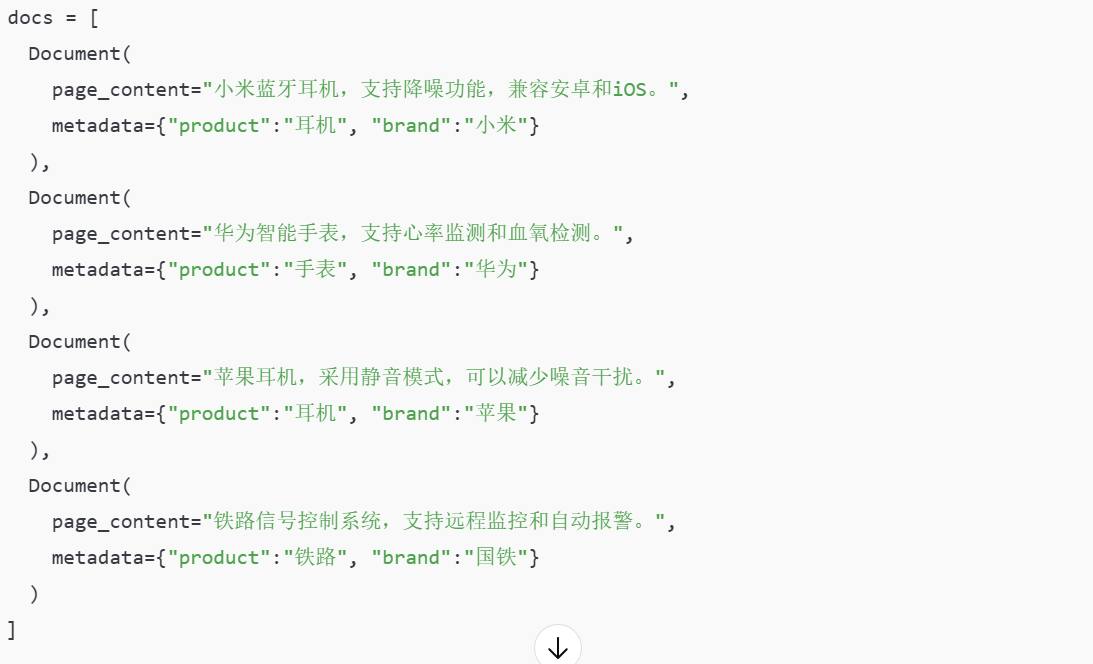

**检索+二次过滤**

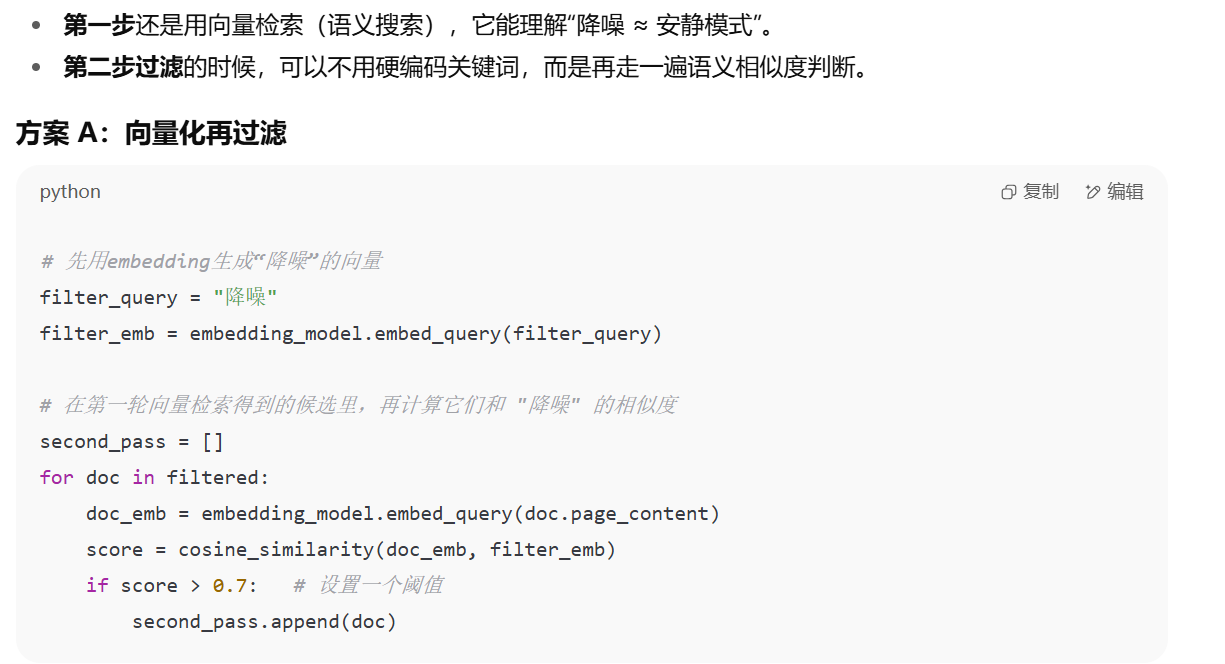

三层组合策略（更精准）

实际项目里常见组合是：

语义检索（向量搜索） → 找“降噪”相关的候选，包括“安静模式”。

Metadata 过滤 → 保证品牌、类别正确，比如 brand=小米，product=耳机。

二次语义过滤 → 再确认文档语义里是否真的有“降噪”的含义（embedding 或 LLM 判断）。

**混合检索**

1. 用 embedding 模型 把这些文档转成向量，存到 FAISS 里。

用户问：

“小米耳机有没有降噪功能？”

向量检索会找到语义最相似的：

小米蓝牙耳机…支持降噪功能 ✅

苹果耳机…静音模式，可以减少噪音 （虽然没有“降噪”二字，但语义相似） ✅

2. 关键词检索（精确匹配）

与此同时，我们也跑一遍传统关键词搜索（BM25 或者简单字符串包含）。

搜索关键词：“小米耳机 降噪”

关键词检索只会找到：

小米蓝牙耳机…支持降噪功能 ✅

3. 混合检索（向量 + 关键词）

把两种结果结合起来，可以有几种策略：

并集（Union）：把向量检索和关键词检索的结果合并，再去重。 → 能保证“语义相关”和“关键词精确”都能被覆盖。

加权融合（Weighted Fusion）：对每个候选文档打分 = α × 语义相似度 + β × 关键词匹配分数，然后排序。

加权融合，例如：

| 文档         | 向量检索得分 | 关键词得分 | 综合得分 (0.6*向量 + 0.4*关键词) |
| ---------- | ------ | ----- | ----------------------- |
| 小米蓝牙耳机（降噪） | 0.95   | 1.0   | 0.97                    |
| 苹果耳机（静音模式） | 0.90   | 0.0   | 0.54                    |
| 华为手表       | 0.10   | 0.0   | 0.06                    |


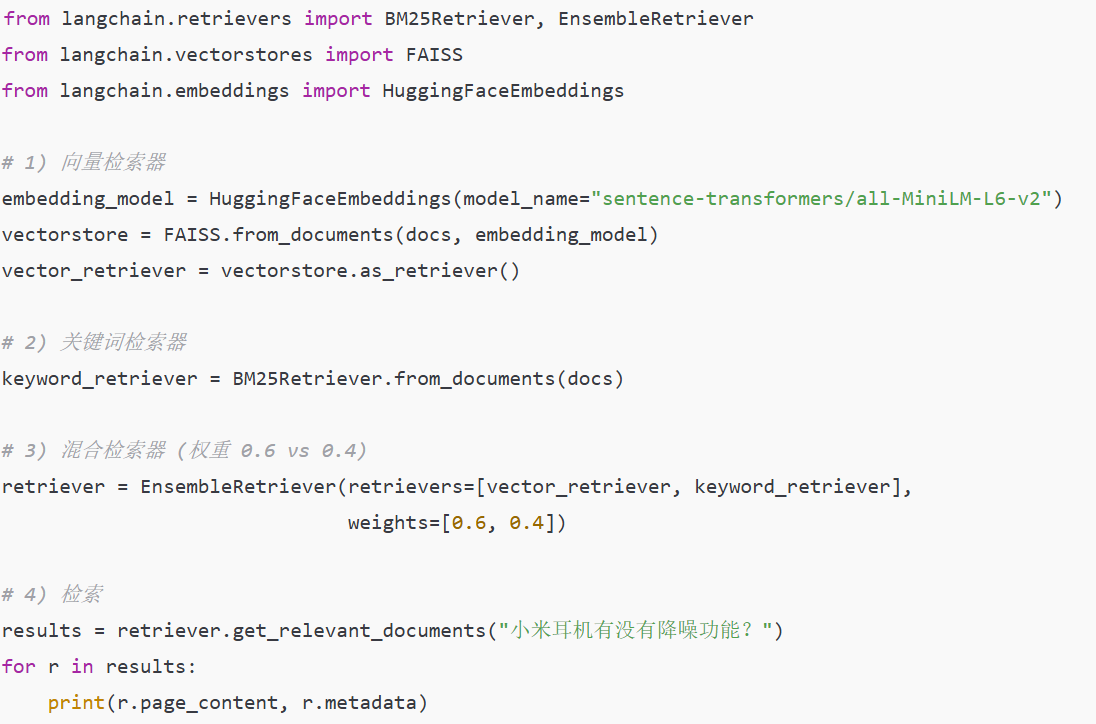

**并集：**

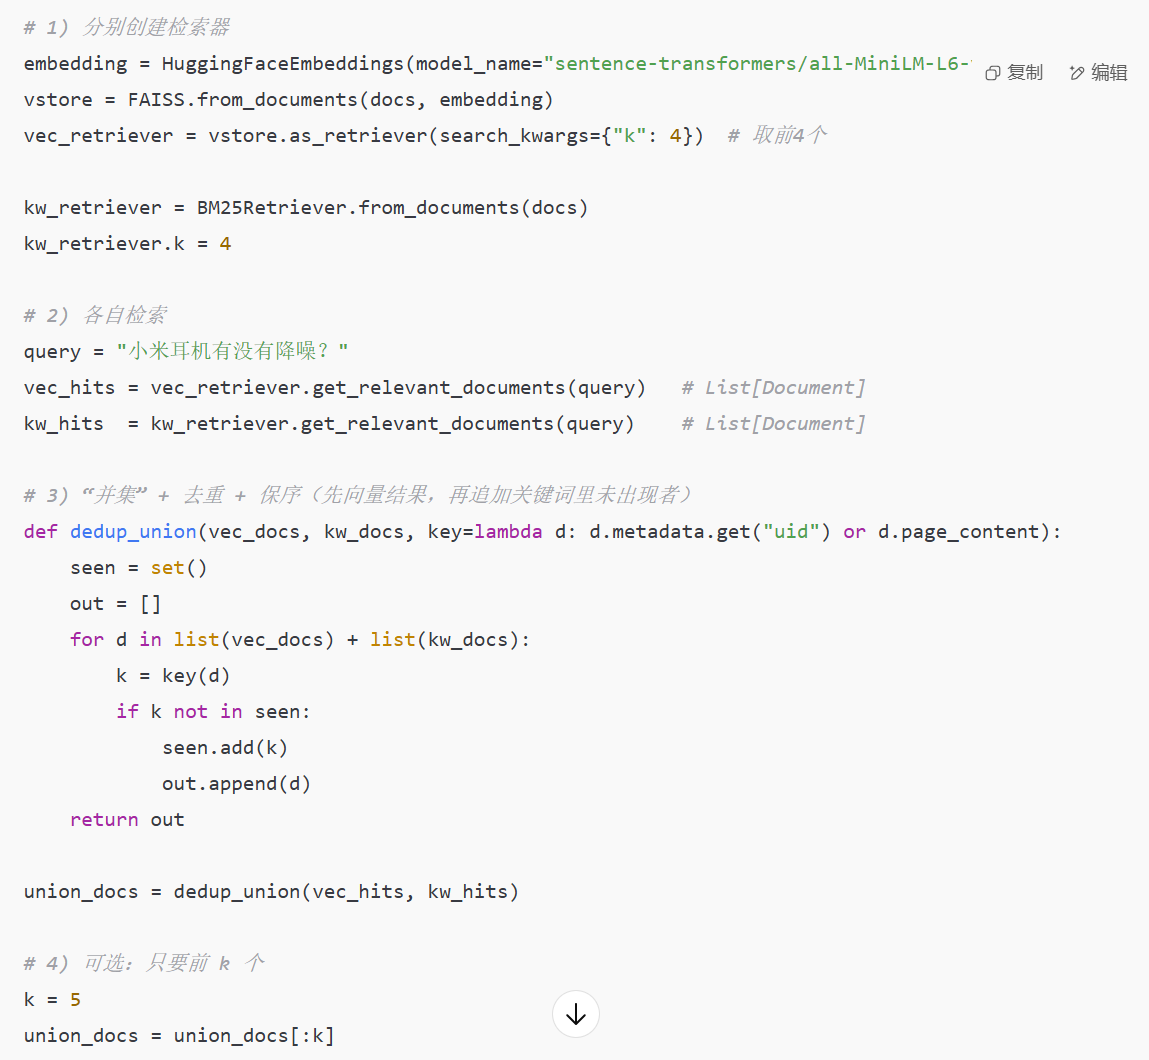

# **多向量数据库+metadata过滤**

先把原始文本变成 Document 对象（每条有正文 + 元数据，比如品牌、品类）。

用同一个 embeddings 模型，把这些 Document 向量化，分别建两个 FAISS 索引：product_db（产品资料）和 policy_db（退货等政策）。

把索引保存到本地磁盘，再从磁盘“重新加载”到内存里（方便下次直接用，不用每次都重新建索引）。

用户问了一个中文问题，你用 jieba 把问句切词（为了后面做简单的“词命中”过滤）。

filter_docs()：拿到一次“向量检索”的结果 search_results 后，再根据元数据里的产品名和用户分词做一次“交集过滤”，尽量只保留与“耳机/手表”等品类吻合的文档，减少噪声。

文档来自不同部门，不同时间。如果不加metadata，可能会检索到错误的信息，错误的版本。

**在 Prompt 阶段的 token**

当你把 检索到的文档拼接进 prompt 时：

这些文字会先经过 tokenizer 切分 → 变成一串 token ID（整数）。

模型输入的就是这些 token ID。

所以这里的 “浪费 token” = 把无关的文本分词后生成的 token，也一并传给模型了。

👉 换句话说：

输入 token：prompt 的长度（文档+问题+指令）。

输出 token：模型生成的答案。

这两部分加起来，决定了你这次调用用了多少 token。

这里的**浪费 token**指：

不必要的文本被拼接进 prompt，消耗了模型的输入 token。

每个 token 相当于一句话的一个“单位”，占用上下文窗口，也增加调用费用。

API 的典型定价结构

按输入（prompt）和输出（completion）分别计费，通常以每 1 百万 tokens（1M tokens） 作为计量单位，以下是几家主流厂商的最新价格数据：

gpt-4o 模型：

输入 $5 / 1M；

输出 $15 / 1M

先用metadata挑出对应时间的数据，再检索。

metadata是 跟我们每条文本相关联的结构化的信息。

检索时会检索出很多文本，但是不是所有文本都和用户查询完全匹配，此时用元数据过滤。

代码如下：

In [25]:
embeddings=DashScopeEmbeddings(model="text-embedding-v1")

In [27]:
from langchain_core.documents import Document

In [28]:
product_docs = [
  Document(
    page_content="小米蓝牙耳机，支持降噪功能，兼容安卓和iOS。",
    metadata={"product":"耳机", "brand":"小米"}
  ),
  Document(
    page_content="华为智能手表，支持心率监测和血氧检测。",
    metadata={"product":"手表", "brand":"华为"}
  ),
  Document(
    page_content="苹果耳机，采用静音模式，可以减少噪音干扰。",
    metadata={"product":"耳机", "brand":"苹果"}
  ),
  Document(
    page_content="铁路信号控制系统，支持远程监控和自动报警。",
    metadata={"product":"铁路", "brand":"国铁"}
  )
]

In [29]:
policy_docs = [
  Document(
    page_content="小米耳机支持7天无理由退货，15天质量问题可换货，1年保修。",
    metadata={"product": "耳机", "brand": "小米"}
  ),
  Document(
    page_content="华为手表支持7天无理由退货，30天内功能性故障可退换，1年保修。",
    metadata={"product": "手表", "brand": "华为"}
  ),
  Document(
    page_content="苹果耳机支持14天内退货，30天内质量问题可换货，1年有限保修。",
    metadata={"product": "耳机", "brand": "苹果"}
  ),
  Document(
    page_content="国铁铁路信号控制系统，交付后不支持无理由退货，质保期2年，提供维修和远程支持。",
    metadata={"product": "铁路", "brand": "国铁"}
  )
]

**1. Document() 是什么？怎么用？**

Document 是 LangChain 里表示“一条可检索知识”的基本单元。它至少有两部分：

page_content：字符串，真正的文本内容（要被向量化、被模型读到的东西）。

metadata：字典，放结构化标签（品牌、产品、来源、页码、文件路径等），方便检索或后过滤。

作用：

向量化时，模型主要看 page_content。

过滤/排序/展示时，metadata 很好用（比如只要“耳机”的结果，或只要“苹果”品牌）。

创建并保存两个向量数据库。

In [31]:
product_db=FAISS.from_documents(product_docs,embeddings)
policy_db=FAISS.from_documents(policy_docs,embeddings)

embeddings 要传入一个 实现了 Embeddings 接口的对象。
常见的有：

OpenAIEmbeddings()（调用 OpenAI 的 text-embedding 模型）

embeddings 不是一个 NumPy 数组，而是一个可以把文本转成向量的“函数对象”。

比如：

embeddings = HuggingFaceEmbeddings(
    
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


In [32]:
product_db.save_local("faiss_product_index")
policy_db.save_local("faiss_policy_index")

重新加载

In [33]:
product_db = FAISS.load_local(
    "faiss_product_index",
    embeddings,
    allow_dangerous_deserialization=True
)
policy_db = FAISS.load_local(
    "faiss_policy_index",
    embeddings,
    allow_dangerous_deserialization=True
)

allow_dangerous_deserialization只应在信任的数据环境下设置为True。

把文件里的向量数据库加载进来。

save_local() 是把内存里的向量库持久化到磁盘；load_local() 是在新的进程/会话里把它再读回内存，以便继续检索，而无需重新嵌入或重新建索引。只有当你重启了笔记本、换了脚本/机器、或想验证保存是否成功时，才需要 load_local()。

**什么时候需要“重新加载”？**

重启/换环境后继续用：避免再次跑一遍嵌入与建索引（省时省钱）。
api.python.langchain.com

线上/离线构建，线上只读：离线构建并 save_local()，线上服务用 load_local() 直接检索。
api.python.langchain.com

验证持久化是否成功：保存后立即 load_local() 做一轮查询，确认可用。

合并或切换索引：把多个库合并或按需切换不同库时，可能需要先加载各自的持久化副本。
LangChain

在同一个 Python 会话里，你已经有 product_db / policy_db 在内存中，保存后可以直接继续用，不必马上 load_local()。

allow_dangerous_deserialization=True 是因为 LangChain 的 docstore 用 pickle 存的；反序列化 pickle 可能执行恶意代码，所以只对你自己保存且可信的文件开启。

**内存（RAM）**：程序运行时的“工作台”。CPU 只能直接读写内存里的字节；断电即失；纳秒级/百纳秒级访问；对象的“引用/指针”指向的就是内存地址。

**磁盘（SSD/HDD）**：长期保存的“仓库”。断电不丢；微秒~毫秒级访问；CPU不能直接用，必须先读到内存后程序才能“引用”。

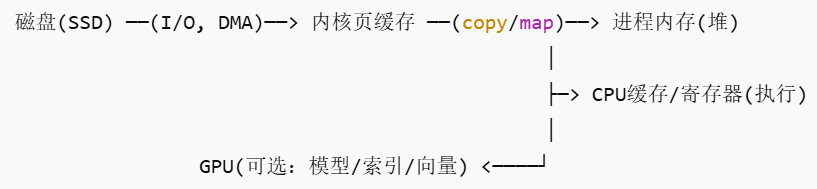

In [35]:
!pip install -q jieba

In [36]:
import re
import jieba


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


In [37]:
#用户查询
query="我买的苹果耳机用了10天还可以退货吗？"
query_tokens=list(jieba.cut(query))
#把用户的问题做了jieba（一个库）的分词，切成"我"，"买"，"的"，"苹果"，"耳机"，"用"，"了"，"14"，"天"，"还"，"可以"，"退货"，"吗"，"？"方便后面做产品名的匹配过滤。
print(f"查询分词：{query_tokens}")

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.636 seconds.
DEBUG:jieba:Loading model cost 0.636 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


查询分词：['我', '买', '的', '苹果', '耳机', '用', '了', '10', '天', '还', '可以', '退货', '吗', '？']


In [38]:
#切完之后做了一个过滤的函数
def filter_docs(search_results,query_tokens):
  filtered=[]
  for doc in search_results:
    product_name=doc.metadata.get("product","")
    product_tokens=list(jieba.cut(product_name))
    #判断query分词和产品分词是否有交集
    if set(query_tokens)&set(product_tokens):
      filtered.append(doc)
  return filtered



遍历检索结果，取出产品名字，通过判断用户查询和产品名称之间是否有交集，有交集就append追加进去。没有交集就过滤出去。

**doc 从哪里来？get("product","") 在做什么？**

doc 的来源：通常来自一次检索结果的迭代:

search_results = product_db.similarity_search(query, k=5)  # 返回 List[Document]

for doc in search_results:

如果用了检索器，就是：

retriever = product_db.as_retriever()

search_results = retriever.get_relevant_documents(query)  # List[Document]

for doc in search_results:

    ...

**.metadata.get("product","") 是** Python 字典的安全取值：

尝试从 doc.metadata 里取键 "product" 的值；

如果没有这个键，就返回默认值 ""（空字符串），避免 KeyError 报错。

换句话说，这行代码是在“拿出这条文档的品类（如耳机/手表），取不到就给个空串”。

**set 的作用？怎么用？**

set(...) 会把一个可迭代对象转成集合：元素唯一、无顺序。

& 是集合的交集运算：返回两个集合里共同出现的元素。

在 if 里用集合交集，等价于“只要交集不为空就为真”，也就是“两边有至少一个相同词”。

**传入的 search_results 应该是什么？属于什么类型？**

search_results 应该是一次向量检索的返回结果，通常是 List[Document]（Python 的 list，元素是 Document 对象）

另外，英文品牌（如 “AirPods”）或同义词（“静音模式”≈“降噪”）会影响命中率，可维护一个同义词/别名表再做扩展匹配。

**doc 不是字典，doc.metadata 才是 Python 字典**

doc：Document 实例，常见字段有

doc.page_content：正文字符串

doc.metadata：字典（放品牌、品类、来源等标签）

doc.metadata.get("product","") 含义：从字典里安全取键 "product"；如果没有该键就返回空字符串 ""，避免 KeyError。

用 doc.metadata["product"] 若缺键会抛 KeyError；.get() 更稳妥。

In [39]:
#分别检索两个库，取前几条
prod_results=product_db.similarity_search(query,k=5)
policy_results=policy_db.similarity_search(query,k=5)

print("\n产品库初筛结果：")
for doc in prod_results:
  print(f"{doc.metadata.get("product")}:{doc.page_content}")

print("\n政策库初筛结果：")
for doc in policy_results:
  print(f"{doc.metadata.get("product")}:{doc.page_content}")


产品库初筛结果：
耳机:苹果耳机，采用静音模式，可以减少噪音干扰。
耳机:小米蓝牙耳机，支持降噪功能，兼容安卓和iOS。
手表:华为智能手表，支持心率监测和血氧检测。
铁路:铁路信号控制系统，支持远程监控和自动报警。

政策库初筛结果：
耳机:苹果耳机支持14天内退货，30天内质量问题可换货，1年有限保修。
耳机:小米耳机支持7天无理由退货，15天质量问题可换货，1年保修。
手表:华为手表支持7天无理由退货，30天内功能性故障可退换，1年保修。
铁路:国铁铁路信号控制系统，交付后不支持无理由退货，质保期2年，提供维修和远程支持。


In [41]:
#过滤
filtered_prod = filter_docs(prod_results,query_tokens)
filtered_policy = filter_docs(policy_results,query_tokens)

print("\n产品库初筛结果：")
for doc in filtered_prod:
  print(f"{doc.metadata.get("product")}:{doc.page_content}")

print("\n政策库初筛结果：")
for doc in filtered_policy:
  print(f"{doc.metadata.get("product")}:{doc.page_content}")


产品库初筛结果：
耳机:苹果耳机，采用静音模式，可以减少噪音干扰。
耳机:小米蓝牙耳机，支持降噪功能，兼容安卓和iOS。

政策库初筛结果：
耳机:苹果耳机支持14天内退货，30天内质量问题可换货，1年有限保修。
耳机:小米耳机支持7天无理由退货，15天质量问题可换货，1年保修。


此时如果query里面的名词和商品库（或者政策库）里面的名词不符合，则过滤后的filtered_prod就是空集。

多知识库（比如一个存商品信息，一个存退货政策，一个存用户反馈。）

在RAG时，如何同时检索多个库，并把内容合并到一起用。

多知识库是企业现实架构。

In [42]:
#合并过滤结果
all_filtered=filtered_prod+filtered_policy

In [43]:
if all_filtered:
  context="\n\n".join([doc.page_content for doc in all_filtered])
else:
  context=None
  print("无搜索结果，知识库内无相关信息。")

用列表推导取出每个 Document 的 page_content（必须是字符串）。

用 "\n\n".join(...) 把它们按原顺序用两个换行拼起来，形成一段长文本，赋给 context。

In [48]:
#调用大语言模型回答
llm=ChatTongyi(model="qwen-turbo",dash_scope_api_key=os.getenv("DASHSCOPE_API_KEY"))

if context:
  prompt=f"""
  请基于以下信息回答用户的问题：
  {context}

  问题:{query}
  请尽量专业地回答。"""
else:
  prompt=f"""
  问题:{query}
  抱歉，知识库里没有找到相关信息，请您联系商家。"""

In [49]:
answer=llm.invoke(prompt)
print("\n===   LLM回答   ===")
print(answer.content)


===   LLM回答   ===
根据您提供的信息，苹果耳机支持**14天内退货**。因此，如果您在购买后**10天内**使用并提出退货申请，**仍然符合退货条件**，可以办理退货手续。

需要注意的是，退货通常需满足以下条件：
- 产品保持完好，未损坏；
- 包装及配件齐全；
- 提供有效的购买凭证（如发票或订单截图）。

建议您在办理退货前，先联系苹果官方客服或购买渠道确认具体流程和要求。


llm 是一个 **Chat 模型对象**（这里是 ChatTongyi）。在 LangChain v0.2+ 里它实现了 Runnable 接口，因此有一套通用方法：**invoke / ainvoke / stream / astream / batch / abatch / bind / with_config **…

**.invoke() 用来单次调用模型：传入一个输入（字符串或消息列表），返回一条 AIMessage。**

**answer 是个 AIMessage 对象**，不是字符串；真正的文本在 answer.content 里，所以你要 print(answer.content)。

| 方法                         | 作用                                                            | 返回值/行为                  | 何时用                               |
| -------------------------- | ------------------------------------------------------------- | ----------------------- | --------------------------------- |
| `invoke(input, **kwargs)`  | 同步单次调用                                                        | 返回 `AIMessage`          | 最常见、最稳妥                           |
| `ainvoke(input, **kwargs)` | 异步单次调用                                                        | `await` 得到 `AIMessage`  | 异步环境                              |
| `stream(input, **kwargs)`  | 同步**流式**输出                                                    | 生成 `AIMessageChunk` 迭代器 | 边出字边打印                            |
| `astream(input, **kwargs)` | 异步流式输出                                                        | 异步迭代器                   | 异步+流式                             |
| `batch(list_of_inputs)`    | 批量调用                                                          | 返回 `List[AIMessage]`    | 多条并行                              |
| `abatch(list_of_inputs)`   | 异步批量                                                          | `List[AIMessage]`       | 异步多条                              |
| `bind(**params)`           | 绑定参数（如 `temperature`、`max_tokens`、`stop`）返回一个“已配置”的新 Runnable | 新的 `llm2`               | 预设推理参数                            |
| `with_config(**run_cfg)`   | 绑定运行配置（tags、metadata、callbacks 等）                             | 新的 Runnable             | 观测、链路追踪                           |
| `predict(text)`\*          | 便捷方法，直接要字符串                                                   | 返回 `str`                | 只要纯文本时（并非所有模型都保留此便捷法，推荐 `invoke`） |


**invoke() 是做什么的？怎么用？**

1. 传入纯字符串（会自动封装为 HumanMessage）

answer = llm.invoke(prompt)   

2. 或者传入“消息列表”（更符合 Chat 语义）

msgs = [

    SystemMessage(content="你是礼貌且专业的客服。"),

    HumanMessage(content=prompt)

]

answer = llm.invoke(msgs)

3. 绑定参数后再调用（推荐把超参固定住）

llm_cold = llm.bind(temperature=0.2, max_tokens=512)

answer = llm_cold.invoke(prompt)

4. 批量

answers = llm.batch(["问1", "问2", "问3"])

for a in answers:

    print(a.content)

5. 流式输出（边出字边打印）

# **上下文连贯对话与记忆功能**

In [ ]:
import os
print("exists?", os.path.exists("/content/.env"))

exists? True


In [ ]:
!pip install -U langchain langchain-community dashscope python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.74
    Uninstalling langchain-core-0.3.74:
      Successfully uninstalled langchain-core-0.3.74
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is 

In [ ]:
from langchain_community.chat_models import ChatTongyi #聊天模型
from langchain.prompts import ChatPromptTemplate #用prompt模板
from langchain.chains import LLMChain #创建对话链
from langchain.memory import ConversationBufferMemory #简单记忆模块，能够自动保存上下文信息。

import os
from dotenv import load_dotenv
load_dotenv()
api_key=os.getenv("DASHSCOPE_API_KEY")

In [ ]:
#初始化大模型
llm=ChatTongyi(
    model_name="qwen-turbo",
    dashscope_api_key=api_key
)

In [ ]:
#定义一个简单的prompt模板
prompt = ChatPromptTemplate.from_template("""
你是一个仔细专业的助理，现在和用户聊天。
请根据对话历史和最新提问，给出自然，有帮助的回答。

对话历史：
{history}

最新提问：
{input}

请回答：
""")

In [ ]:
#初始化记忆模块
#使用ConversationBufferMemory把上下文内容存储到"history"里面去
memory = ConversationBufferMemory(memory_key="history",return_messages="True")

# 在 Prompt 里用 {history} 读取历史
# 历史以“消息对象列表”返回，而不是拼成一串文本

/tmp/ipython-input-2044532413.py:3: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(memory_key="history",return_messages="True")


它具体做了什么？

记录历史：把每次的 Human/Ai 消息顺序保存在内部缓冲区（buffer）里。

提供给 Prompt：以后每次调用链/代理时，会把这份历史注入到你 Prompt 的 {history} 占位符里。

返回格式：

return_messages=True：{history} 会是一串 HumanMessage/AIMessage 列表（适合聊天模型）。

return_messages=False（默认）：{history} 是一段已拼好的长文本（适合纯文本 LLM）。

参数解释

memory_key="history"：这决定了你在 Prompt 里用哪个变量名接收历史。比如 {history}。

return_messages=True：是否以“消息列表”形式返回；聊天模板通常更喜欢这种形式。

**history列表里都存什么？**

有 return_messages=True 时，历史会以“消息对象列表”保存并注入到 {history}。你之前那条“如何用雨果的风格续写小说”会作为一条 HumanMessage 对象出现在列表里（紧跟着通常还有当时模型的 AIMessage 回复）。它不是“一行纯文本”，而是“带角色与内容的消息对象”。

它保存的是完整原文，不会自动摘要/去重。对话很长时可改用 ConversationBufferWindowMemory(k=…) 或 ConversationTokenBufferMemory(...) 控制长度。

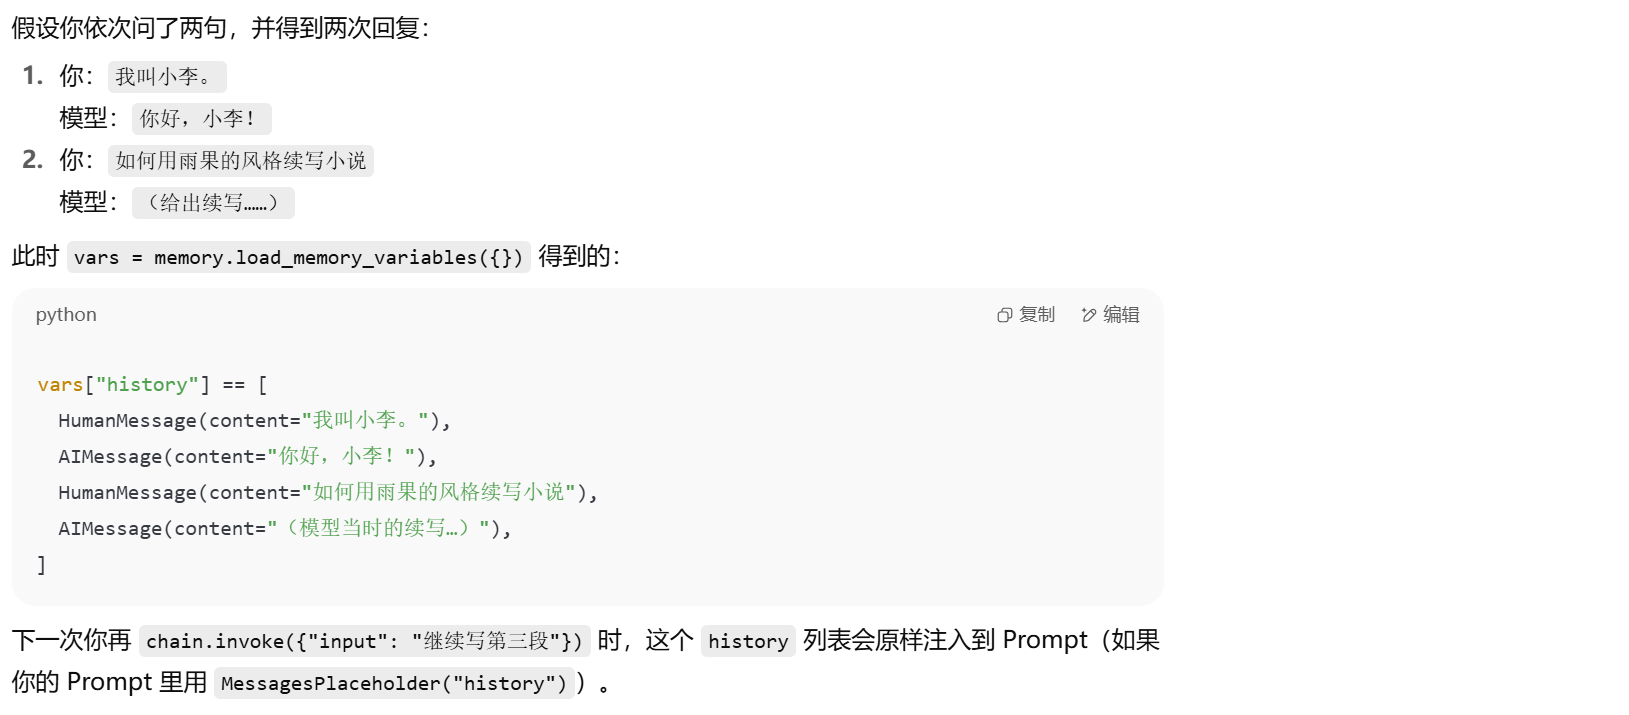

In [ ]:
#创建langchain对话链，链式操作=任务串联起来，链条=任务
chain=LLMChain(
    llm=llm,
    prompt=prompt,
    memory=memory
)

/tmp/ipython-input-935721178.py:2: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain=LLMChain(


此时我们直接拥有了记忆的功能

In [ ]:
#开始多轮对话 检索+生成
print(chain.invoke({'input':"你能帮我写一个python版本的hello world程序吗？"})["text"])
# 内存为空 → 填模板 → 调模型 → 回答（text）→ 把这轮问答写入内存
print("=======================================================================")
print(chain.invoke({'input':"再帮我写一个Java版本的。"})["text"])
# 这次内存里已经有上一轮的对话历史 → 填入 {history} → 调模型 → 回答（text）→ 继续写回内存

当然可以！下面是一个简单的 Python 版本的 "Hello, World!" 程序：

```python
print("Hello, World!")
```

当你运行这段代码时，它会在控制台输出：

```
Hello, World!
```

如果你需要更详细的解释或扩展功能，随时告诉我！
当然可以！下面是一个简单的 Java 版本的 "Hello, World!" 程序：

```java
public class HelloWorld {
    public static void main(String[] args) {
        System.out.println("Hello, World!");
    }
}
```

### 说明：
- `public class HelloWorld`：定义一个公共类，类名必须与文件名相同（例如 `HelloWorld.java`）。
- `public static void main(String[] args)`：这是 Java 程序的入口点。
- `System.out.println("Hello, World!");`：在控制台输出 "Hello, World!"。

保存为 `HelloWorld.java` 文件，然后使用 Java 编译器编译并运行即可。如果有其他问题或需要扩展功能，随时告诉我！


无论是提示模板（Prompt）、模型（LLM/ChatModel），还是链（Chain），它们在 LangChain 里都实现了同一个“可运行（Runnable）”接口；因此都有 .invoke() 方法。

prompt.invoke(inputs)：把 inputs 填进模板，产出“可投喂给模型的消息/文本”（ChatPromptValue）。

llm.invoke(formatted)：把上一步的结果送进模型，产出模型回复（通常是 AIMessage）。

chain.invoke(inputs)：把整条链跑完：取内存 → 填模板 → 调模型 → 解析输出 → 写回内存，最后给你结果。

一句话：.invoke() = 运行这一步/这一层应做的事，并把结果返回。

需要并发/批量：用 chain.batch([{"input": ...}, {"input": ...}])

需要流式输出：用 chain.stream({"input": ...})

需要异步：用 await chain.ainvoke(...)（在异步环境里）

LLMChain.invoke() 返回的是一个 dict，而且这个字典里默认只有一个键："text"。所以你才能写：

chain.invoke({'input': "..."})["text"]

LLMChain 有一个属性叫 output_key，默认值是 "text"。

因此 invoke() 的返回结构固定为：{"text": "<模型生成的内容>"}。

**其他存储的类型**，比如说ChatMessageHistory聊天消息历史。

需要手动存储，代码如下。

In [ ]:
#创建消息历史对象
message_history=ChatMessageHistory()
#创建代理是的链
chain_with_history=RunnableWithMessageHistory(
    chain,
    lambda session_id:memory
    input_message_key="input"
    #未完
)

#第一句对话
input1="who you are?"
response1= chain_with_history.invoke({"input":input1},config={"configurable":{"session_id"}})
#保存到历史中
message_history.add_user_message(input1)
message_history.add_ai_message(response1.content)

chain是可复用的提问逻辑板块。

# **在实际搭建多向量知识库里常见的问题。**

**1. 如何更改FAISS的参数来提高召回率？**

| 场景规模（文档/段落数N） | 首选索引                     | 余弦/IP | 主要旋钮建议                                                              | 备注               |
| ------------- | ------------------------ | ----- | ------------------------------------------------------------------- | ---------------- |
| ≤ 50k         | `IndexFlatIP`            | 是     | `k=20–50`                                                           | 用作最高召回基线；够快就直接用  |
| 50k–200k      | `IVFFlat`                | 是     | `nlist=2k–8k`，`nprobe=32–128`                                       | 首次落地优先选          |
| 200k–1M       | `IVF_HNSW` 或 `IVFPQ+OPQ` | 是     | `nlist=8k–16k`；HNSW: `M=32`/`efSearch=100–200`；PQ: `m=48`/`nbits=8` | 内存/延迟双平衡         |
| ≥ 1M          | `IVFPQ+OPQ`              | 是     | `nlist=16k+`，`nprobe=128–256`，`m=64`，`nbits=8`                      | 先做网格实验选 Pareto 点 |


**2. 大模型输出不太稳定的时候，提示词的模板怎么写？**

目标是让输出更稳定、可控、可评估。每套模板都强调：只依据检索片段回答、固定输出结构、缺信息要明确说明。

**1) 全局 System 提示（放在 system）**

你是“铁路维修技术助手”。你的职责是：基于提供的【已检索文档片段】回答用户问题。
硬性规则：
1) 只使用检索片段中的信息，不要加入外部知识或臆测。
2) 当信息不足时，明确说明“依据现有文档无法确认”，并给出需要的补充信息清单。
3) 严格遵循输出格式，不要输出多余字段或改变字段名。
4) 安全优先：若问题涉及作业或检修，必须先给出安全警示与停电/防护前置步骤（若文档有）。
5) 引用规范：每一条关键结论后必须附上片段ID列表（如 ["D12","D27"]）。


**2) RAG 问答模板（JSON 稳定版）**

[输入变量]
- 用户问题：{{question}}
- 检索片段（数组）：{{contexts}}
  // contexts 元素格式：
  // { "id":"D1", "source":"xxxx.pdf#p12", "text":"……原文……" }

[指令]
请仅基于上述检索片段回答。若多个片段冲突，优先引用发布时间最新、与问题匹配度最高的片段。
生成以下 JSON（不要多余文本）：

{
  "answer": "<面向一线人员的清晰回答。若涉及操作，先给安全警示。>",
  "citations": ["<片段ID>", "..."],
  "confidence": "<high|medium|low>",
  "reasoning_note": "<不超过50字的简短理由，不暴露推理过程细节>",
  "follow_up": ["<最多2条可澄清/补充的问题>", "..."],
  "unanswered": {
    "is_unanswered": <true|false>,
    "missing_info": ["<若无法回答，需要的关键信息点>", "..."]
  }
}

生成规则：
- answer 里的每个关键结论都必须能在 citations 指向的片段中找到证据。
- 若证据不足，将 is_unanswered 置为 true，并在 answer 中明确提示“依据现有片段无法确认”。
- confidence 评估原则：证据充足一致=high；部分缺失或有冲突=medium；关键证据缺失=low。


**3) 故障诊断/处置（SOP）模板（适合检修决策类）**

确保输出步骤化、可执行且安全优先。

[输入]
- 问题：{{question}}
- 片段：{{contexts}}

[任务]
请基于片段生成结构化SOP（JSON）。不要编造片段不存在的信息。

{
  "safety_first": [
    "<作业前安全措施1>",
    "<作业前安全措施2>"
  ],
  "quick_checks": [
    {"step":"<快速排查点>","why":"<目的>","cite":["D.."]},
    {"step":"...","why":"...","cite":["D.."]}
  ],
  "diagnostic_flow": [
    {"if":"<条件A>","then":"<动作/下一步>","cite":["D.."]},
    {"if":"<条件B>","then":"<动作/下一步>","cite":["D.."]}
  ],
  "tools_required": ["<工具/工装>"],
  "limits": ["<适用范围或限制条件>"],
  "notes": ["<注意事项>"],
  "citations": ["D..","D.."],
  "confidence": "<high|medium|low>",
  "unanswered": {
    "is_unanswered": <true|false>,
    "missing_info": ["<必须补充的测量值/环境信息>"]
  }
}

规则：
- safety_first 必须放在最前，且仅来自片段。
- 每个关键步骤附 cite。
- 不确定时给出分支条件而非武断结论。


**“自检清单”后缀（粘到所有模板结尾，提升稳定性）**

在给出最终输出前，逐项自检（不要展示过程）：
- [ ] 是否完全遵守指定的输出结构与字段名？
- [ ] 是否每个关键结论都有片段ID支撑？
- [ ] 是否先给出安全相关内容（若适用）？
- [ ] 信息不足是否显式标记并列出缺口？
- [ ] 是否避免了通用常识与臆测？

**使用建议**

固定格式 + 少量 Few-shot：同一任务保留 1–2 个“高质量示例”（问→片段→输出），能显著稳定风格。

温度设低：配合以上模板，将 temperature=0–0.3、top_p=0.8–1.0。

检索侧配合：保证每个 contexts[i].id 稳定可回溯（如 “D{docId}_p{page}_c{chunk}”）。

解析器（若用 LangChain）：用 StructuredOutputParser / PydanticOutputParser 校验 JSON，避免漂移。

# **Dify: 0代码构建RAG知识库**

不懂代码，想要快速搭建RAG

导入已有文本 = 在代码里创建的数据知识库

索引方式 里面的 嵌入模型：把文本变成向量，然后去faiss里做相似度的检索。

做相似度检索必须创造索引。

# **Rerank**

通过rerank模型，对检索的知识重新排序，一般rerank模型比较大，需要过一遍transformer的架构。

相当于需要依据问题和相关的每个知识片段，通过rerank模型进行摘要的提取和比对，看谁接近答案。计算量很大，所以top-k一般10-20个。对这找出来的10个进行重排序。

rerank实际上是对query和片段进行意图识别。类似于阅读理解。


# **提升RAG质量的方法**



**数据阶段：**

1. 数据评估与分类：

审查现有数据，识别过时，矛盾信息。

按类型和重要性对数据进行分类。

2。 数据清洗：

去重，纠错，更新，一致性检查。

3. 数据标记与标注：

元数据标记。

对非结构化数据进行标注，便于检索。

4. 智能文档技术（比如阿里的）

将非结构化数据（pdf,图片，excel，markdown）变成结构化数据。然后再做切片。

或者pdf处理器处理pdf。

举例RagFlow底层逻辑OCR，处理pdf。

**知识检索阶段**

遇到的问题：

1. 内容缺失，切片切太碎了，只找到其中一小片。

2. 错过排名靠前的文档，top-k的k值太小。

3. 不在生成答案的上下文中，检索出了段落却没出现在上下文中，通常发生在返回大量文件需要进行整合时。



方法：

1. 意图识别。

2. 混合检索（关键字检索挑10段，向量检索挑10段，一共20段）和重排策略（对20段重排，拿到最后相似度最高的5段）。

具体：

***意图识别：***

第一种方法：RAG Fusion

解决的问题是用户也许不知道他想要什么，提出的query不合理。

把用户的原始query扩展成多个不同但相关的查询（query expansion）；

然后分别去检索，把多个检索结果进行融合（fusion）；

最终形成一个更全面、更robust的上下文，再交给大模型回答。

这里有一个langchain提供的框架。

In [ ]:
retriever=MultiQueryRetriever.from_llm(
    retriver=vectorstore.as_retriver(),
    llm=llm
)
#生成多个查询
#分别用这些query进行检索

NameError: name 'MultiQueryRetriever' is not defined

使用了MultiQueryRetriever后还想要递归检索，该怎么实现？

你先用更细的向量检索命中，再“递归”拿回上层大段，得到更完整上下文。

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_core.documents import Document
from langchain.retrievers.multi_query import MultiQueryRetriever

# 1) 你的向量检索器
vectorstore = FAISS(...)  # 已构建
# 2) 父子检索器（递归式层级展开）
parent_ret = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=InMemoryDocstore(),  # 或你自己的KV存储
    child_splitter=RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=60),
    parent_splitter=RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200),
)

# 3) 再用 MultiQuery 做“多查询扩展 + 多路检索”
mq_ret = MultiQueryRetriever.from_llm(
    retriever=parent_ret,   # 注意参数名是 retriever
    llm=llm,
    include_original=True
)

docs = mq_ret.invoke("你的问题")


TypeError: FAISS.__init__() missing 3 required positional arguments: 'index', 'docstore', and 'index_to_docstore_id'

**混合检索和重排策略**

用户询问“信用卡年费多少”

之间检索可能返回大量文档，部分相关文档排名低。

步骤：

1. 查询理解与扩展（Multi-Query）
把“年费”扩成同义/近义查询：年费标准/年费金额/年费收费/免年费条件/年费减免/刷免门槛；把“信用卡”扩成 卡片/主卡/副卡/白金/金卡/Visa/Master 等（适配你卡种域内同义词表）。

2. 混合检索

BM25（关键词检索）：擅长抓“年费、¥、RMB、USD、元”等显著词+数字。

向量检索（语义）：使用嵌入模型，能补到“免年费”“达标免首年”等语义变体。

用 RRF（Reciprocal Rank Fusion） 融合两路结果，互补长短。

3. 重排（Cross-Encoder / API Rerank）

让重排器对“查询 ↔ 文档片段”做交互式打分，优先含金额与“年费”强匹配的片段，并倾向最新版本/生效日期最近的条款。


In [ ]:
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever
from langchain.retrievers.multi_query import MultiQueryRetriever

# --- 1) 向量检索器（dense） ---
emb = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
vectorstore = FAISS.from_documents(docs, emb)  # 你的文档集 docs
dense_ret = vectorstore.as_retriever(search_kwargs={"k": 12})

# --- 2) 关键词检索器（sparse / BM25） ---
bm25_ret = BM25Retriever.from_documents(docs)
bm25_ret.k = 12

# --- 3) RRF 融合为“混合检索器” ---
hybrid_ret = EnsembleRetriever(
    retrievers=[bm25_ret, dense_ret],
    weights=[0.5, 0.5],  # 可按集验证调参
)

# --- 4) Multi-Query 扩展（查询改写）---
from langchain_core.prompts import PromptTemplate
# 针对“年费”场景的中文扩展模板（可加自有同义词表）
mq_prompt = PromptTemplate.from_template(
    "把用户问题改写成 3-5 个等价/互补的检索查询，覆盖年费金额/年费标准/免年费条件等不同表述。\n"
    "用户问题：{query}\n"
    "只输出每行一个查询："
)
# llm = ...  # 你现有的 LLM
mqr = MultiQueryRetriever.from_llm(
    retriever=hybrid_ret,
    llm=llm,
    prompt=mq_prompt,
    include_original=True
)

# --- 5) Cross-Encoder 重排（开源） ---
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain.retrievers import ContextualCompressionRetriever

ce = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")  # 也可用 large，效果更好耗时更高
reranker = CrossEncoderReranker(model=ce, top_n=6)  # 只保留与查询最相关的6段

final_ret = ContextualCompressionRetriever(
    base_retriever=mqr,
    compressor=reranker
)

query = "招商银行白金信用卡年费多少？"
top_docs = final_ret.get_relevant_documents(query)

# （可选）再做一个简单的金额优先排序：包含“年费/￥/元/RMB/免年费”的片段再轻微加权
import re
def has_fee_signal(text):
    return bool(re.search(r"(年费|￥|\bRMB\b|CNY|元|\$|USD)", text))
top_docs.sort(key=lambda d: (has_fee_signal(d.page_content), len(d.page_content)), reverse=True)

# top_docs 交给你的答案生成链做抽取/回答